<a href="https://colab.research.google.com/github/alvin23laguera/FC-Midtjylland---UEFA-Europa-League-MD-6-8-/blob/main/MidtjyllandUEL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from google.colab import drive
import os

# 1. Montamos drive (necesario en cada notebook nuevo)
drive.mount('/content/drive')

# 2. Ruta al archivo procesado
path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'
file_name = "FC Midtjylland vs KRC Genk.csv"
df = pd.read_csv(os.path.join(path_processed, file_name))

# 3. Diagnóstico rápido de columnas clave
print("--- DATOS GENERALES ---")
print(f"Total de eventos: {len(df)}")
print(f"Columnas disponibles: {df.columns.tolist()[:15]}...") # Vemos las primeras 15

# 4. Identificar Equipos (Para saber cuál es el Midtjylland)
# Normalmente en Opta aparece como 'teamId' o 'team_id'
team_id_candidates = [col for col in df.columns if 'team' in col.lower() and 'id' in col.lower()]

if team_id_candidates:
    team_col = team_id_candidates[0]
    print(f"\n--- EQUIPOS ENCONTRADOS (ID) ---")
    print(df[team_col].unique())
else:
    print("\n--- ADVERTENCIA: No se encontró una columna 'team' y 'id' en el DataFrame. ---")
    print("Por favor, examine las columnas disponibles para identificar la que contiene la información del equipo.")
    print("Columnas disponibles:", df.columns.tolist())
    print("Intentando buscar columnas que contengan 'team' o 'name' para identificar equipos.")

    # Fallback: Try to find a column that looks like a team name
    team_name_cols = [col for col in df.columns if 'team' in col.lower() or 'name' in col.lower()]
    if team_name_cols:
        team_col = team_name_cols[0] # Pick the first one as a best guess
        print(f"\n--- COLUMNA DE EQUIPO SUGERIDA (PRIMERA COINCIDENCIA): '{team_col}' ---")
        print(f"Valores únicos en '{team_col}':")
        try:
            print(df[team_col].unique())
        except KeyError:
            print(f"No se pudo acceder a la columna '{team_col}'.")
            team_col = None
    else:
        print("\nNo se encontraron columnas que contengan 'team' o 'name' para identificar equipos.")
        team_col = None

# 5. Identificar Jugadores y Coordenadas
player_cols = [col for col in df.columns if 'player' in col.lower()]
coord_cols = [col for col in df.columns if col.lower() in ['x', 'y', 'startx', 'starty']]

print(f"\n--- COLUMNAS DE JUGADORES ---")
print(player_cols)
print(f"\n--- COLUMNAS DE COORDENADAS ---")
print(coord_cols)

# Vemos las primeras filas de estas columnas clave
print("\n--- MUESTRA DE DATOS ---")

# Prepare columns for display, ensuring team_col is included only if found
cols_to_display = []
if team_col:
    cols_to_display.append(team_col)
cols_to_display.extend(player_cols[:2])
cols_to_display.extend(coord_cols)

if cols_to_display:
    display(df[cols_to_display].head())
else:
    print("No hay columnas suficientes para mostrar una vista previa después de identificar el equipo. Mostrando el head general del DataFrame.")
    display(df.head()) # Fallback to display general head if no specific columns identified.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
--- DATOS GENERALES ---
Total de eventos: 1
Columnas disponibles: ['matchInfo.id', 'matchInfo.coverageLevel', 'matchInfo.date', 'matchInfo.time', 'matchInfo.localDate', 'matchInfo.localTime', 'matchInfo.week', 'matchInfo.numberOfPeriods', 'matchInfo.periodLength', 'matchInfo.var', 'matchInfo.lastUpdated', 'matchInfo.description', 'matchInfo.sport.id', 'matchInfo.sport.name', 'matchInfo.ruleset.id']...

--- ADVERTENCIA: No se encontró una columna 'team' y 'id' en el DataFrame. ---
Por favor, examine las columnas disponibles para identificar la que contiene la información del equipo.
Columnas disponibles: ['matchInfo.id', 'matchInfo.coverageLevel', 'matchInfo.date', 'matchInfo.time', 'matchInfo.localDate', 'matchInfo.localTime', 'matchInfo.week', 'matchInfo.numberOfPeriods', 'matchInfo.periodLength', 'matchInfo.var', 'matchInfo.lastUpdated', 'matchInfo.descript

,matchInfo.sport.name
0,Soccer


In [ ]:
import pandas as pd
import json
import os

# 1. Cargamos el JSON original (desde Raw para no perder información)
path_raw = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Raw'
file_name = "FC Midtjylland vs KRC Genk"

with open(os.path.join(path_raw, file_name), 'r', encoding='utf-8') as f:
    content = f.read()
    # Aplicamos la limpieza que ya conocemos para el JSONP
    start_idx = content.find('{') if content.find('{') != -1 else content.find('[')
    end_idx = content.rfind('}') if content.rfind('}') != -1 else content.rfind(']')
    data = json.loads(content[start_idx : end_idx + 1])

# 2. LA CLAVE: Extraemos la lista de eventos que está en liveData -> event
df_events = pd.json_normalize(data['liveData']['event'])

# 3. Guardamos este nuevo CSV (el de verdad) en Processed
path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'
df_events.to_csv(os.path.join(path_processed, "Midtjylland_Genk_Events.csv"), index=False)

# 4. Inspección rápida del nuevo DataFrame
print(f"✅ ¡Ahora sí! Total de eventos: {len(df_events)}")
print("\nPrimeras columnas de eventos:")
print(df_events.columns.tolist()[:15])

# Buscamos de nuevo los IDs de equipo
team_col = 'teamId' # En este nivel suele llamarse así directamente
if team_col in df_events.columns:
    print(f"\nEquipos encontrados: {df_events[team_col].unique()}")

✅ ¡Ahora sí! Total de eventos: 1725

Primeras columnas de eventos:
['id', 'eventId', 'typeId', 'periodId', 'timeMin', 'timeSec', 'contestantId', 'outcome', 'x', 'y', 'timeStamp', 'lastModified', 'qualifier', 'playerId', 'playerName']


In [ ]:
# Vemos qué jugadores están asociados a cada contestantId
for team in df_events['contestantId'].unique():
    sample_players = df_events[df_events['contestantId'] == team]['playerName'].dropna().unique()[:3]
    print(f"ID del equipo: {team} - Jugadores de muestra: {list(sample_players)}")

ID del equipo: 59as3grjvj19voay31j3yfgni - Jugadores de muestra: ['P. Billing', 'A. Şimşir', 'Cho Gue-Sung']
ID del equipo: 89xivtxk59uzvhdsd6miao6tm - Jugadores de muestra: ['P. Hrošovský', 'H. Van Crombrugge', 'D. Heymans']


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.5/88.5 kB 4.4 MB/s eta 0:00:00


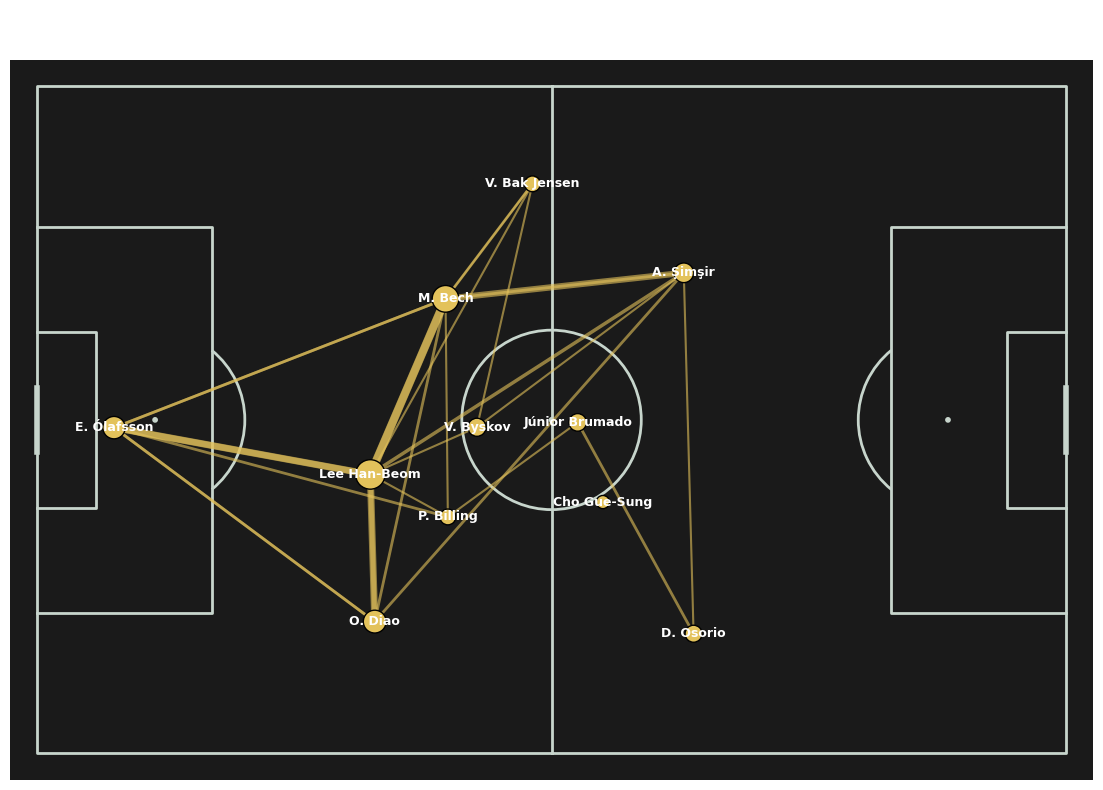

In [ ]:
!pip install mplsoccer
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# --- CONFIGURACIÓN ---
TEAM_ID = '59as3grjvj19voay31j3yfgni'  # <--- Pon aquí el ID que descubras en el paso anterior
df = df_events.copy()

# 1. Filtramos: Solo pases del Midtjylland que fueron exitosos
# typeId 1 = Pass, outcome 1 = Success
passes = df[(df['contestantId'] == TEAM_ID) & (df['typeId'] == 1) & (df['outcome'] == 1)].copy()

# 2. (Opcional) Filtrar hasta el primer cambio para mayor precisión táctica
# Si no quieres complicarte ahora, puedes saltarte este paso
first_sub_time = df[(df['typeId'] == 40)]['timeMin'].min() # 40 suele ser Substitution
if pd.notnull(first_sub_time):
    passes = passes[passes['timeMin'] < first_sub_time]

# 3. Calculamos posiciones medias de cada jugador
avg_locations = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
avg_locations.columns = ['x', 'y', 'count']

# 4. Calculamos pases entre parejas de jugadores
# Creamos una columna con el receptor (es el jugador que hace el siguiente evento)
passes['receptor'] = passes['playerName'].shift(-1)
# Filtramos pases donde el receptor no es nulo y es del mismo equipo
pass_between = passes.groupby(['playerName', 'receptor']).id.count().reset_index()
pass_between.rename(columns={'id': 'pass_count'}, inplace=True)

# --- VISUALIZACIÓN ---
pitch = Pitch(pitch_type='opta', pitch_color='#1a1a1a', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(12, 8))

# Dibujamos las líneas (pases entre jugadores)
# Solo dibujamos si hay más de 2 o 3 pases para no "ensuciar" el gráfico
for i, row in pass_between.iterrows():
    if row['pass_count'] > 2:
        player1 = row['playerName']
        player2 = row['receptor']

        # Obtenemos coordenadas de los dos jugadores
        if player1 in avg_locations.index and player2 in avg_locations.index:
            p1_loc = avg_locations.loc[player1]
            p2_loc = avg_locations.loc[player2]

            # El grosor de la línea depende de la cantidad de pases
            width = row['pass_count'] / 2
            pitch.lines(p1_loc.x, p1_loc.y, p2_loc.x, p2_loc.y,
                        lw=width, color='#E3C25B', zorder=1, alpha=0.6, ax=ax)

# Dibujamos los nodos (jugadores)
nodes = pitch.scatter(avg_locations.x, avg_locations.y,
                      s=avg_locations['count']*10, color='#E3C25B', edgecolors='#000000', linewidth=1, alpha=1, zorder=2, ax=ax)

# Añadimos los nombres
for index, row in avg_locations.iterrows():
    pitch.annotate(index, xy=(row.x, row.y), c='white', va='center', ha='center', size=9, weight='bold', ax=ax)

plt.title(f"Passing Network: FC Midtjylland vs KRC Genk", color='white', size=20, pad=20)
plt.show()

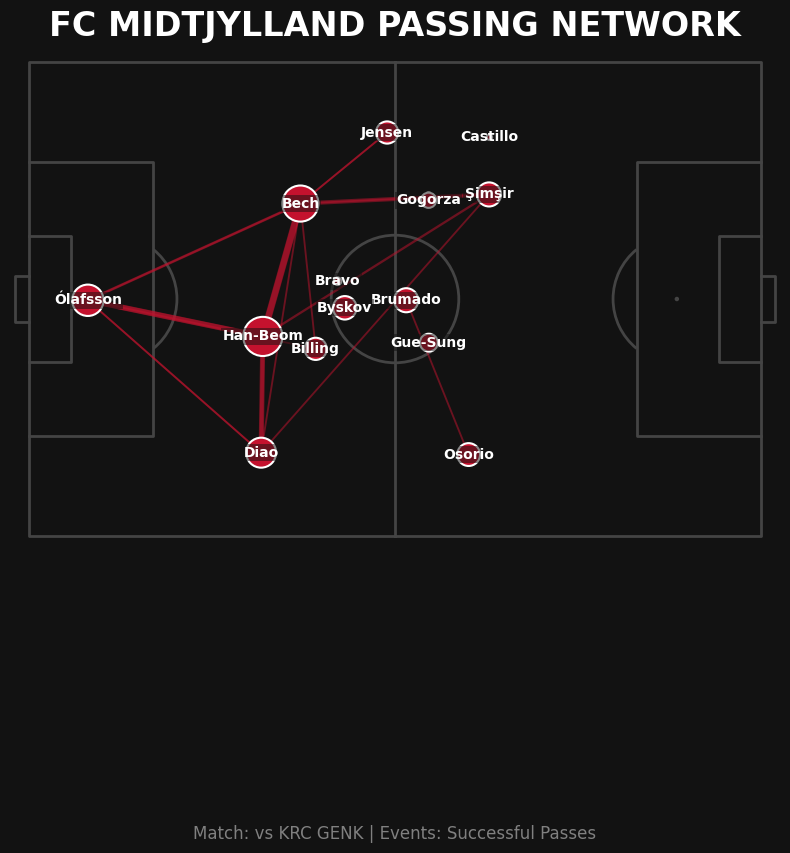

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch

# --- CONFIGURACIÓN ESTÉTICA ---
TEAM_NAME = "FC MIDTJYLLAND"
OPPONENT = "KRC GENK"
MAIN_COLOR = "#C4122E" # El rojo característico del Midtjylland
BG_COLOR = "#121212"   # Fondo negro profundo para que el rojo resalte

# 1. Filtramos datos (Asegúrate de tener definido TEAM_ID de la celda anterior)
passes = df_events[(df_events['contestantId'] == TEAM_ID) &
                   (df_events['typeId'] == 1) &
                   (df_events['outcome'] == 1)].copy()

# 2. Posiciones medias y conteo
avg_locations = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
avg_locations.columns = ['x', 'y', 'count']

# 3. Relación de pases
passes['receptor'] = passes['playerName'].shift(-1)
pass_between = passes.groupby(['playerName', 'receptor']).id.count().reset_index()
pass_between.rename(columns={'id': 'pass_count'}, inplace=True)

# --- VISUALIZACIÓN VERTICAL ---
# pitch_type='opta' porque tus datos son 0-100.
# orientation='vertical' para girar el campo.
pitch = Pitch(pitch_type='opta',
              pitch_color=BG_COLOR, line_color='#444444',
              goal_type='box')

fig, ax = pitch.draw(figsize=(8, 12))
fig.set_facecolor(BG_COLOR)

# Dibujamos las líneas de pases
for i, row in pass_between.iterrows():
    if row['pass_count'] > 3: # Filtro para no saturar
        p1 = avg_locations.loc[row['playerName']]
        p2 = avg_locations.loc[row['receptor']]

        # El grosor escala con el número de pases
        lw = row['pass_count'] / 3
        pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=lw,
                    color=MAIN_COLOR, alpha=0.5, zorder=1, ax=ax)

# Dibujamos los nodos de los jugadores
nodes = pitch.scatter(avg_locations.x, avg_locations.y,
                      s=avg_locations['count']*15, color=MAIN_COLOR,
                      edgecolors='white', linewidth=1.5, alpha=1, zorder=2, ax=ax)

# Añadimos etiquetas de nombres
for index, row in avg_locations.iterrows():
    # Ajustamos un poco el texto para que sea legible en vertical
    pitch.annotate(index.split(' ')[-1], # Solo el apellido para no saturar
                   xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=10, weight='bold',
                   bbox=dict(facecolor=BG_COLOR, alpha=0.5, edgecolor='none', pad=1),
                   ax=ax)

# Títulos en inglés
plt.title(f"{TEAM_NAME} PASSING NETWORK", color='white', size=24, weight='bold', pad=-20)
plt.figtext(0.5, 0.05, f"Match: vs {OPPONENT} | Events: Successful Passes",
            ha='center', color='gray', size=12)

plt.show()

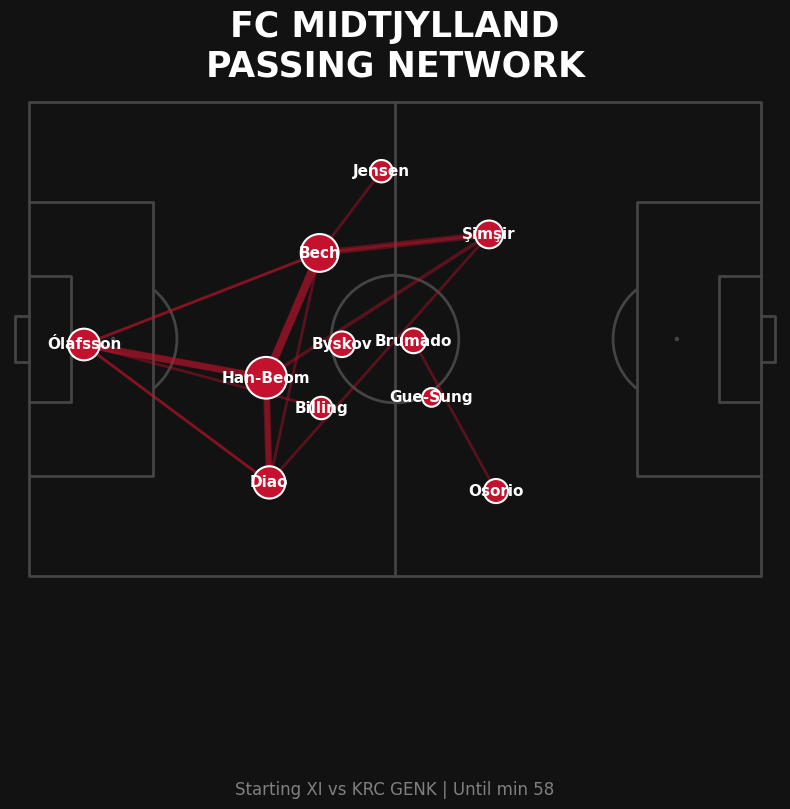

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd

# 1. Definir el momento del primer cambio para limpiar la red
# Buscamos el typeId 40 (Sustitución)
sub_events = df_events[df_events['typeId'] == 40]
if not sub_events.empty:
    first_sub_min = sub_events['timeMin'].min()
else:
    first_sub_min = 60 # Si no hay datos, cortamos al 60 por seguridad

# 2. Filtrar pases: Solo Midtjylland, exitosos, y ANTES del primer cambio
passes = df_events[
    (df_events['contestantId'] == TEAM_ID) &
    (df_events['typeId'] == 1) &
    (df_events['outcome'] == 1) &
    (df_events['timeMin'] < first_sub_min)
].copy()

# 3. Calcular posiciones medias
avg_locations = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
avg_locations.columns = ['x', 'y', 'count']

# 4. Calcular red de pases entre jugadores
passes['receptor'] = passes['playerName'].shift(-1)
pass_between = passes.groupby(['playerName', 'receptor']).id.count().reset_index()
pass_between.rename(columns={'id': 'pass_count'}, inplace=True)

# --- VISUALIZACIÓN VERTICAL ---
# Usamos orientation='vertical' y nos aseguramos de que el pitch sea 'opta'
pitch = Pitch(pitch_type='opta',
              pitch_color='#121212', line_color='#444444',
              goal_type='box')

fig, ax = pitch.draw(figsize=(8, 12))
fig.set_facecolor('#121212')

# Dibujar líneas (solo si hay una conexión mínima de 3 pases)
for i, row in pass_between.iterrows():
    if row['pass_count'] > 3:
        # Solo dibujamos si ambos jugadores están en nuestro top 11 inicial
        if row['playerName'] in avg_locations.index and row['receptor'] in avg_locations.index:
            p1 = avg_locations.loc[row['playerName']]
            p2 = avg_locations.loc[row['receptor']]
            pitch.lines(p1.x, p1.y, p2.x, p2.y,
                        lw=row['pass_count']/2, color='#C4122E',
                        alpha=0.4, zorder=1, ax=ax)

# Dibujar los nodos (jugadores)
pitch.scatter(avg_locations.x, avg_locations.y,
              s=avg_locations['count']*20, color='#C4122E',
              edgecolors='white', linewidth=1.5, zorder=2, ax=ax)

# Anotaciones de los apellidos
for index, row in avg_locations.iterrows():
    pitch.annotate(index.split(' ')[-1],
                   xy=(row.x, row.y), c='white', va='center',
                   ha='center', size=11, weight='bold', ax=ax)

# Títulos profesionales
plt.title("FC MIDTJYLLAND\nPASSING NETWORK", color='white', size=25, weight='bold', pad=-30)
plt.figtext(0.5, 0.12, f"Starting XI vs {OPPONENT} | Until min {first_sub_min}",
            ha='center', color='gray', size=12)

plt.show()

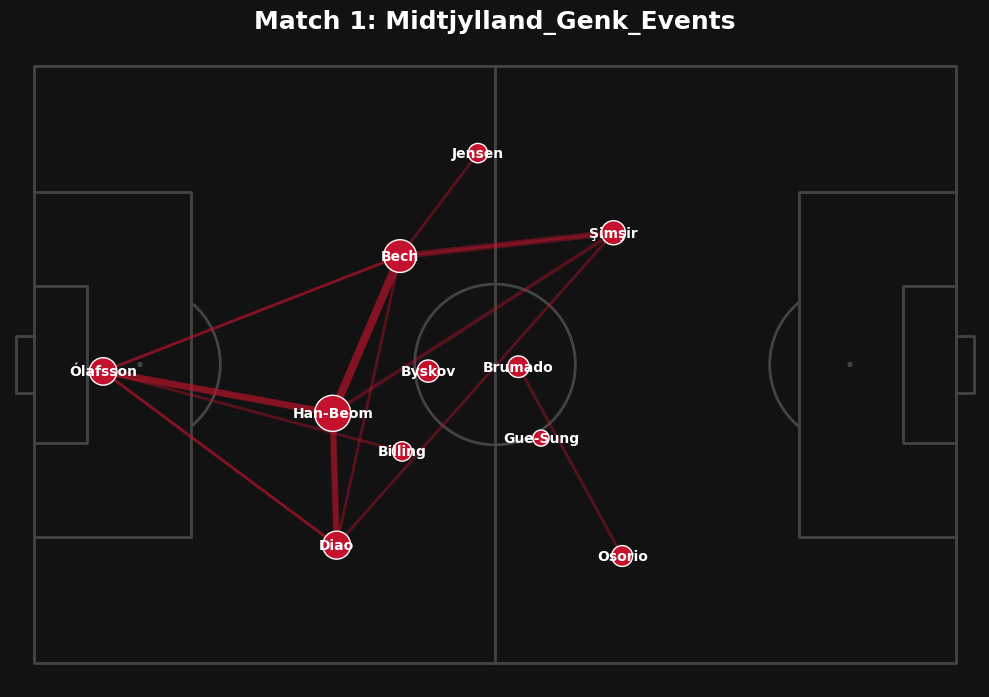

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os

# --- CONFIGURACIÓN ---
path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'
# Asegúrate de usar los nombres exactos de tus archivos CSV procesados
# Debes apuntar a los archivos CSV que contienen los eventos, no los metadatos.
archivos_csv = [
    "Midtjylland_Genk_Events.csv"
    # Si tienes otros archivos de eventos (ej. "SK Brann_Events.csv", "Dinamo Zagreb_Events.csv"), añádelos aquí.
]
TEAM_ID = '59as3grjvj19voay31j3yfgni' # Sustituye por el ID numérico del Midtjylland

# Creamos la figura con 3 subplots (3 filas, 1 columna)
# Añadimos squeeze=False para asegurar que axs siempre sea un array 2D, incluso con una sola fila/columna
fig, axs = plt.subplots(nrows=len(archivos_csv), ncols=1, figsize=(10, 30), squeeze=False)
fig.set_facecolor('#121212')

for i, nombre_archivo in enumerate(archivos_csv):
    # 1. Cargar datos
    df_match = pd.read_csv(os.path.join(path_processed, nombre_archivo))

    # 2. Identificar el primer cambio para filtrar titulares
    sub_events = df_match[df_match['typeId'] == 40]
    first_sub = sub_events['timeMin'].min() if not sub_events.empty else 60

    # 3. Filtrar pases exitosos del FCM antes del primer cambio
    passes = df_match[
        (df_match['contestantId'] == TEAM_ID) &
        (df_match['typeId'] == 1) &
        (df_match['outcome'] == 1) &
        (df_match['timeMin'] < first_sub)
    ].copy()

    # 4. Posiciones medias y red de pases
    avg_locs = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
    avg_locs.columns = ['x', 'y', 'count']

    passes['receptor'] = passes['playerName'].shift(-1)
    pass_net = passes.groupby(['playerName', 'receptor']).size().reset_index(name='pass_count')

    # --- DIBUJO ---
    # Usamos el eje actual (axs[i][0] porque squeeze=False crea un array 2D)
    pitch = Pitch(pitch_type='opta', # Probamos horizontal para la cuadrícula
                  pitch_color='#121212', line_color='#444444', goal_type='box')
    pitch.draw(ax=axs[i][0])

    # Líneas de pases (más de 3 pases)
    for _, row in pass_net.iterrows():
        if row['pass_count'] > 3 and row['playerName'] in avg_locs.index and row['receptor'] in avg_locs.index:
            p1 = avg_locs.loc[row['playerName']]
            p2 = avg_locs.loc[row['receptor']]
            pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=row['pass_count']/2,
                        color='#C4122E', alpha=0.4, zorder=1, ax=axs[i][0])

    # Nodos de jugadores
    pitch.scatter(avg_locs.x, avg_locs.y, s=avg_locs['count']*15,
                  color='#C4122E', edgecolors='white', linewidth=1, zorder=2, ax=axs[i][0])

    # Etiquetas (Apellidos)
    for index, row in avg_locs.iterrows():
        pitch.annotate(index.split(' ')[-1], xy=(row.x, row.y), c='white',
                       va='center', ha='center', size=10, weight='bold', ax=axs[i][0])

    # Título por partido
    axs[i][0].set_title(f"Match {i+1}: {nombre_archivo.replace('.csv', '')}",
                     color='white', size=18, weight='bold', pad=10)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import json
import os

path_raw = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Raw'
path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'
archivos = ["FC Midtjylland vs KRC Genk", "SK Brann vs FC Midtjylland", "FC Midtjylland vs Dinamo Zagreb"]

for nombre in archivos:
    file_path = os.path.join(path_raw, nombre)
    if os.path.exists(file_path):
        with open(file_path, 'r', encoding='utf-8') as f:
            content = f.read()
            # Limpieza de JSONP (buscamos el corazón de los datos)
            start = content.find('{') if content.find('{') != -1 else content.find('[')
            end = content.rfind('}') if content.rfind('}') != -1 else content.rfind(']')
            data = json.loads(content[start : end + 1])

            # Extraemos la lista de eventos real
            df_events = pd.json_normalize(data['liveData']['event'])

            # Guardamos con el nombre limpio
            df_events.to_csv(os.path.join(path_processed, f"{nombre}.csv"), index=False)
            print(f"✅ Cofre abierto y guardado: {nombre}.csv (Eventos: {len(df_events)})")

✅ Cofre abierto y guardado: FC Midtjylland vs KRC Genk.csv (Eventos: 1725)
✅ Cofre abierto y guardado: SK Brann vs FC Midtjylland.csv (Eventos: 1737)
✅ Cofre abierto y guardado: FC Midtjylland vs Dinamo Zagreb.csv (Eventos: 1731)


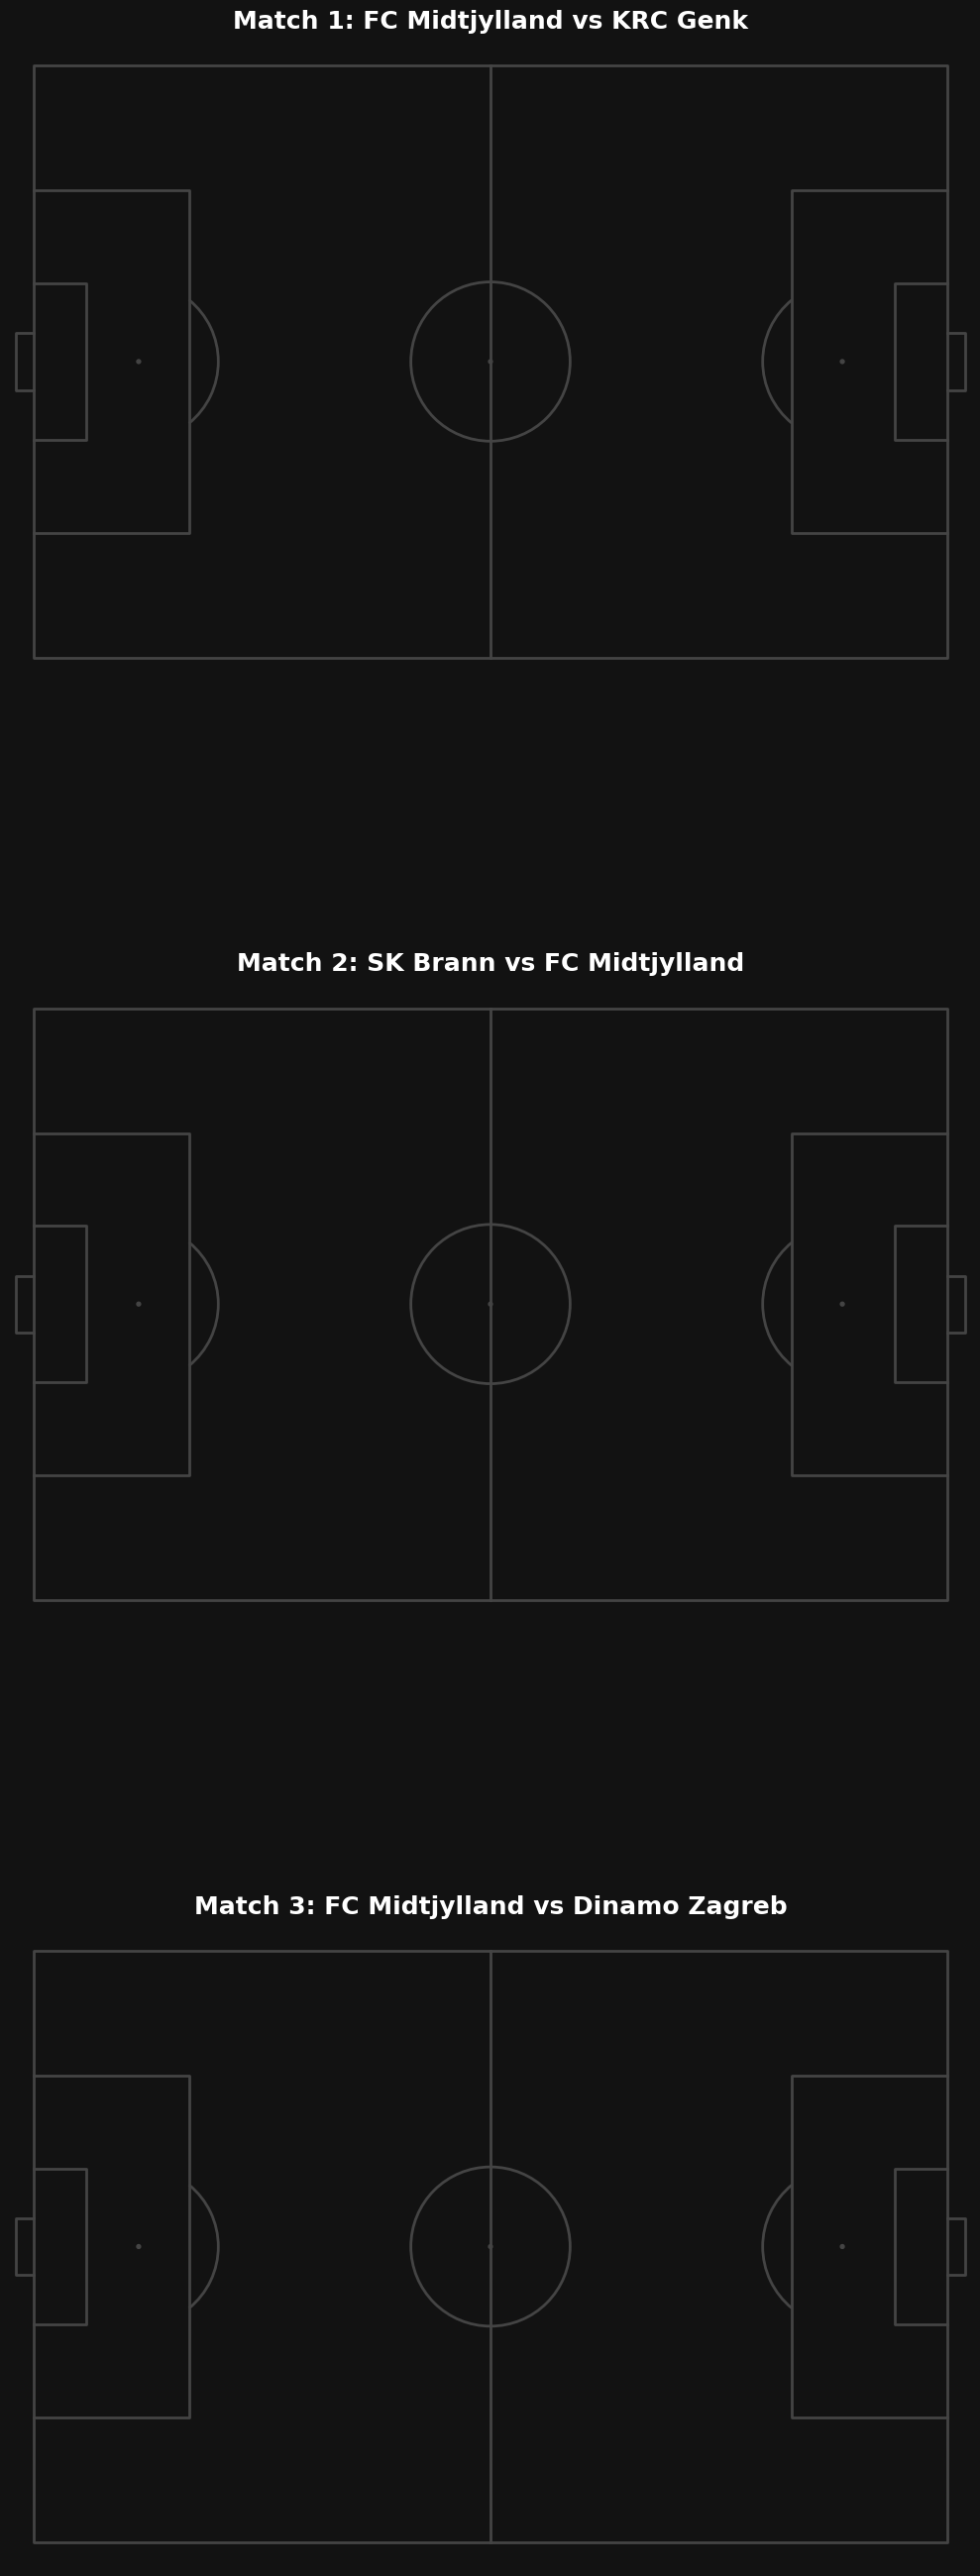

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os

# --- CONFIGURACIÓN ---
path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'
# Asegúrate de usar los nombres exactos de tus archivos CSV procesados
archivos_csv = [
    "FC Midtjylland vs KRC Genk.csv",
    "SK Brann vs FC Midtjylland.csv",
    "FC Midtjylland vs Dinamo Zagreb.csv"
]
TEAM_ID = 'TU_ID_AQUÍ' # Sustituye por el ID numérico del Midtjylland

# Creamos la figura con 3 subplots (3 filas, 1 columna)
fig, axs = plt.subplots(nrows=len(archivos_csv), ncols=1, figsize=(10, 30))
fig.set_facecolor('#121212')

for i, nombre_archivo in enumerate(archivos_csv):
    # 1. Cargar datos
    df_match = pd.read_csv(os.path.join(path_processed, nombre_archivo))

    # 2. Identificar el primer cambio para filtrar titulares
    sub_events = df_match[df_match['typeId'] == 40]
    first_sub = sub_events['timeMin'].min() if not sub_events.empty else 60

    # 3. Filtrar pases exitosos del FCM antes del primer cambio
    passes = df_match[
        (df_match['contestantId'] == TEAM_ID) &
        (df_match['typeId'] == 1) &
        (df_match['outcome'] == 1) &
        (df_match['timeMin'] < first_sub)
    ].copy()

    # 4. Posiciones medias y red de pases
    avg_locs = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
    avg_locs.columns = ['x', 'y', 'count']

    passes['receptor'] = passes['playerName'].shift(-1)
    pass_net = passes.groupby(['playerName', 'receptor']).size().reset_index(name='pass_count')

    # --- DIBUJO ---
    # Usamos el eje actual (axs[i])
    pitch = Pitch(pitch_type='opta', # Probamos horizontal para la cuadrícula
                  pitch_color='#121212', line_color='#444444', goal_type='box')
    pitch.draw(ax=axs[i])

    # Líneas de pases (más de 3 pases)
    for _, row in pass_net.iterrows():
        if row['pass_count'] > 3 and row['playerName'] in avg_locs.index and row['receptor'] in avg_locs.index:
            p1 = avg_locs.loc[row['playerName']]
            p2 = avg_locs.loc[row['receptor']]
            pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=row['pass_count']/2,
                        color='#C4122E', alpha=0.4, zorder=1, ax=axs[i])

    # Nodos de jugadores
    pitch.scatter(avg_locs.x, avg_locs.y, s=avg_locs['count']*15,
                  color='#C4122E', edgecolors='white', linewidth=1, zorder=2, ax=axs[i])

    # Etiquetas (Apellidos)
    for index, row in avg_locs.iterrows():
        pitch.annotate(index.split(' ')[-1], xy=(row.x, row.y), c='white',
                       va='center', ha='center', size=10, weight='bold', ax=axs[i])

    # Título por partido
    axs[i].set_title(f"Match {i+1}: {nombre_archivo.replace('.csv', '')}",
                     color='white', size=18, weight='bold', pad=10)

plt.tight_layout()
plt.show()

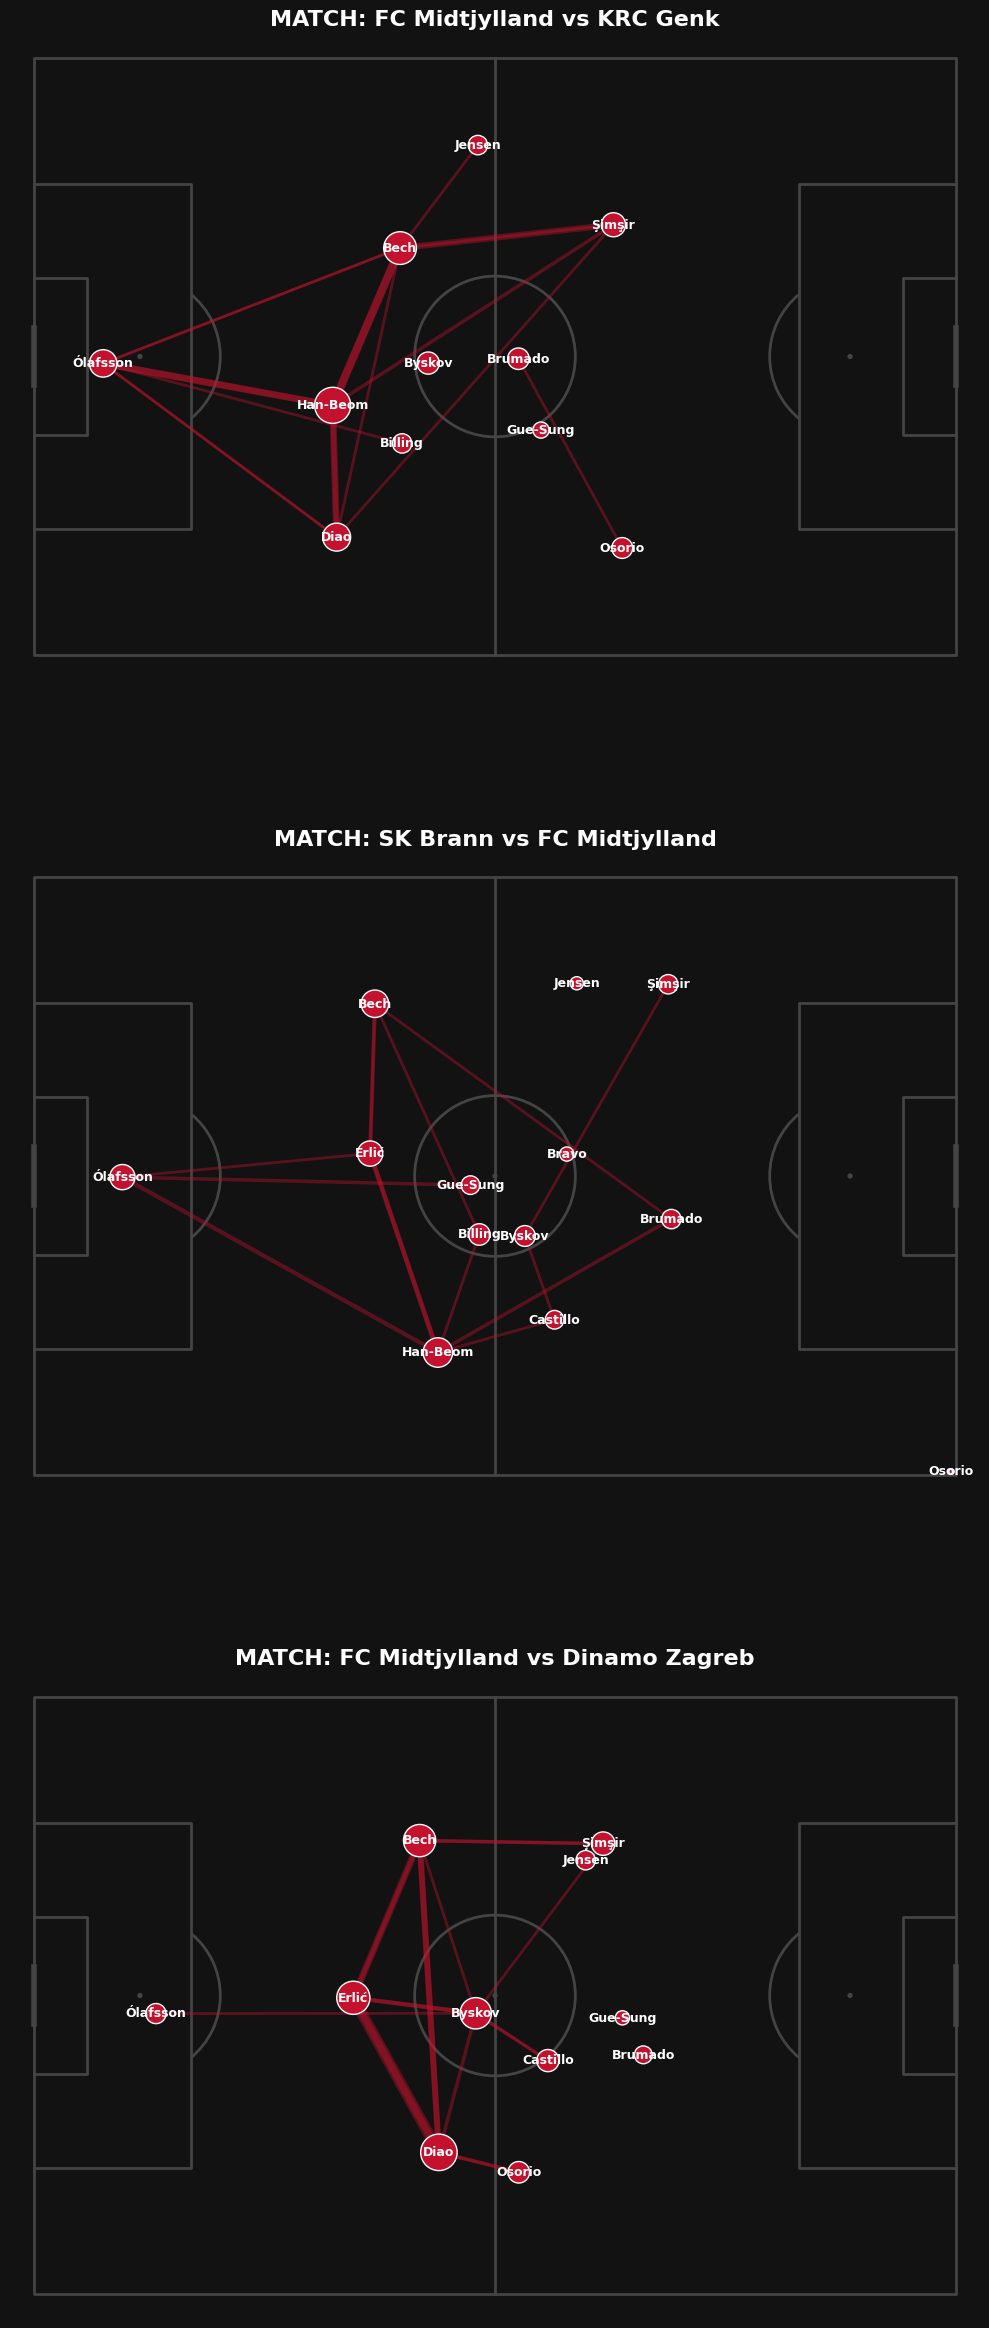

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os

path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'
archivos_csv = [
    "FC Midtjylland vs KRC Genk.csv",
    "SK Brann vs FC Midtjylland.csv",
    "FC Midtjylland vs Dinamo Zagreb.csv"
]

fig, axs = plt.subplots(nrows=len(archivos_csv), ncols=1, figsize=(10, 25))
fig.set_facecolor('#121212')

for i, nombre_archivo in enumerate(archivos_csv):
    df_match = pd.read_csv(os.path.join(path_processed, nombre_archivo))

    # --- AUTO-DETECCIÓN DEL ID DEL MIDTJYLLAND ---
    # Buscamos qué contestantId tiene jugadores con nombre "Sørensen", "Dalsgaard" o "Cho" (clásicos del FCM)
    # O más fácil: el que tenga más eventos si el archivo es solo de sus pases
    ids_disponibles = df_match['contestantId'].unique()

    # Para estar seguros, elegimos el ID que más pases tiene en el archivo
    # (Asumiendo que el Midtjylland es nuestro foco)
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # 1. Filtro de titulares (antes del primer cambio)
    sub_events = df_match[df_match['typeId'] == 40]
    first_sub = sub_events['timeMin'].min() if not sub_events.empty else 65

    # 2. Filtrar pases exitosos
    passes = df_match[
        (df_match['contestantId'] == fcm_id) &
        (df_match['typeId'] == 1) &
        (df_match['outcome'] == 1) &
        (df_match['timeMin'] < first_sub)
    ].copy()

    # 3. Procesar Red
    avg_locs = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
    avg_locs.columns = ['x', 'y', 'count']

    passes['receptor'] = passes['playerName'].shift(-1)
    pass_net = passes.groupby(['playerName', 'receptor']).size().reset_index(name='pass_count')

    # --- DIBUJO ---
    pitch = Pitch(pitch_type='opta', pitch_color='#121212', line_color='#444444')
    pitch.draw(ax=axs[i])

    if not avg_locs.empty:
        # Líneas
        for _, row in pass_net.iterrows():
            if row['pass_count'] > 3 and row['playerName'] in avg_locs.index and row['receptor'] in avg_locs.index:
                p1 = avg_locs.loc[row['playerName']]
                p2 = avg_locs.loc[row['receptor']]
                pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=row['pass_count']/2,
                            color='#C4122E', alpha=0.4, zorder=1, ax=axs[i])

        # Nodos
        pitch.scatter(avg_locs.x, avg_locs.y, s=avg_locs['count']*15,
                      color='#C4122E', edgecolors='white', linewidth=1, zorder=2, ax=axs[i])

        # Apellidos
        for index, row in avg_locs.iterrows():
            pitch.annotate(index.split(' ')[-1], xy=(row.x, row.y), c='white',
                           va='center', ha='center', size=9, weight='bold', ax=axs[i])
    else:
        axs[i].text(50, 50, "DATOS NO ENCONTRADOS PARA ESTE ID", color='white', ha='center')

    axs[i].set_title(f"MATCH: {nombre_archivo.split(' vs ')[0]} vs {nombre_archivo.split(' vs ')[1].replace('.csv','')}",
                     color='white', size=16, weight='bold')

plt.tight_layout()
plt.show()

--- FC Midtjylland vs KRC Genk.csv ---
11 Titulares (por minutos): ['O. Diao', 'P. Billing', 'Cho Gue-Sung', 'E. Ólafsson', 'V. Bak Jensen', 'Lee Han-Beom', 'M. Bech', 'D. Osorio', 'Júnior Brumado', 'V. Byskov', 'A. Şimşir']
--- SK Brann vs FC Midtjylland.csv ---
11 Titulares (por minutos): ['E. Ólafsson', 'M. Bech', 'Lee Han-Beom', 'D. Castillo', 'V. Bak Jensen', 'Júnior Brumado', 'M. Erlić', 'Cho Gue-Sung', 'A. Şimşir', 'V. Byskov', 'P. Billing']
--- FC Midtjylland vs Dinamo Zagreb.csv ---
11 Titulares (por minutos): ['D. Castillo', 'M. Bech', 'V. Byskov', 'Cho Gue-Sung', 'O. Diao', 'V. Bak Jensen', 'A. Şimşir', 'Júnior Brumado', 'M. Erlić', 'E. Ólafsson', 'D. Osorio']


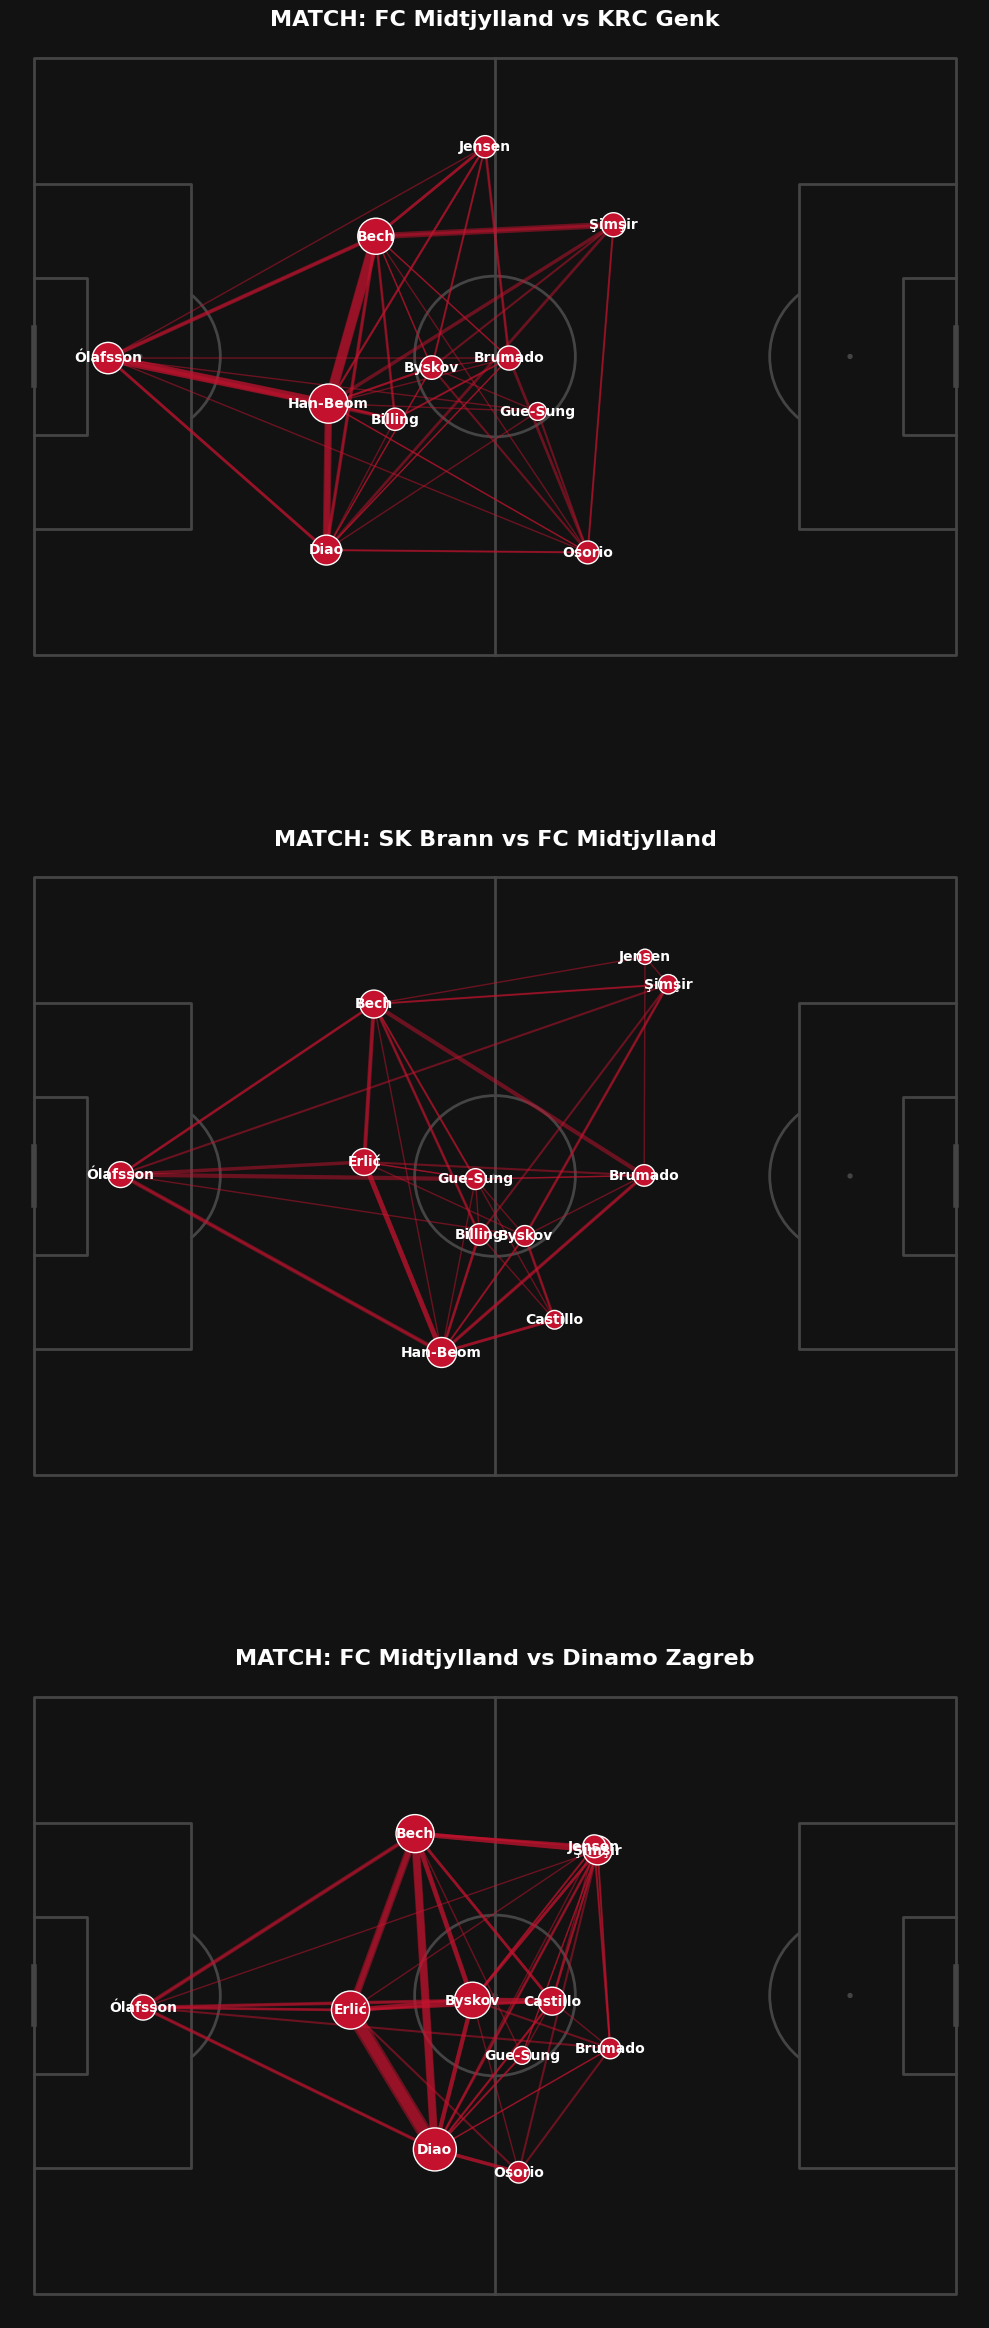

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os

path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'
archivos_csv = [
    "FC Midtjylland vs KRC Genk.csv",
    "SK Brann vs FC Midtjylland.csv",
    "FC Midtjylland vs Dinamo Zagreb.csv"
]

fig, axs = plt.subplots(nrows=len(archivos_csv), ncols=1, figsize=(10, 25))
fig.set_facecolor('#121212')

for i, nombre_archivo in enumerate(archivos_csv):
    # 1. Cargar Datos y Detectar Equipo
    df_match = pd.read_csv(os.path.join(path_processed, nombre_archivo))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # Filtramos solo eventos del Midtjylland
    df_team = df_match[df_match['contestantId'] == fcm_id].copy()

    # 2. LÓGICA DE MINUTOS JUGADOS (Proxy: Última acción - Primera acción)
    # Calculamos el rango de tiempo de actividad de cada jugador
    player_minutes = df_team.groupby('playerName')['timeMin'].agg(['min', 'max'])
    player_minutes['minutes_played'] = player_minutes['max'] - player_minutes['min']

    # Seleccionamos los 11 jugadores con mayor rango de actividad
    top_11_minutes = player_minutes.sort_values('minutes_played', ascending=False).head(11).index.tolist()

    print(f"--- {nombre_archivo} ---")
    print(f"11 Titulares (por minutos): {top_11_minutes}")

    # 3. FILTRAR Y PREPARAR PASES (Solo de estos 11 cracks)
    passes = df_team[
        (df_team['typeId'] == 1) &
        (df_team['outcome'] == 1) &
        (df_team['playerName'].isin(top_11_minutes))
    ].copy()

    # Calculamos posiciones medias
    avg_locs = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
    avg_locs.columns = ['x', 'y', 'count']

    # Calculamos conexiones
    passes['receptor'] = passes['playerName'].shift(-1)
    pass_net = passes.groupby(['playerName', 'receptor']).size().reset_index(name='pass_count')

    # --- DIBUJO ---
    pitch = Pitch(pitch_type='opta', pitch_color='#121212', line_color='#444444')
    pitch.draw(ax=axs[i])

    # Dibujar líneas (Bajamos el filtro a >1 para ver estructura en partidos difíciles)
    for _, row in pass_net.iterrows():
        if row['pass_count'] > 1:
            if row['receptor'] in top_11_minutes and row['playerName'] in top_11_minutes:
                p1 = avg_locs.loc[row['playerName']]
                p2 = avg_locs.loc[row['receptor']]

                # Grosor según intensidad de pase
                width = row['pass_count'] / 2
                pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=width,
                            color='#C4122E', alpha=0.5, zorder=1, ax=axs[i])

    # Dibujar Nodos
    if not avg_locs.empty:
        pitch.scatter(avg_locs.x, avg_locs.y, s=avg_locs['count']*15,
                      color='#C4122E', edgecolors='white', linewidth=1, zorder=2, ax=axs[i])

        # Etiquetas (Apellidos)
        for index, row in avg_locs.iterrows():
            pitch.annotate(index.split(' ')[-1], xy=(row.x, row.y), c='white',
                           va='center', ha='center', size=10, weight='bold', ax=axs[i])

    # Títulos
    axs[i].set_title(f"MATCH: {nombre_archivo.replace('.csv','')}",
                     color='white', size=16, weight='bold')

plt.tight_layout()
plt.show()

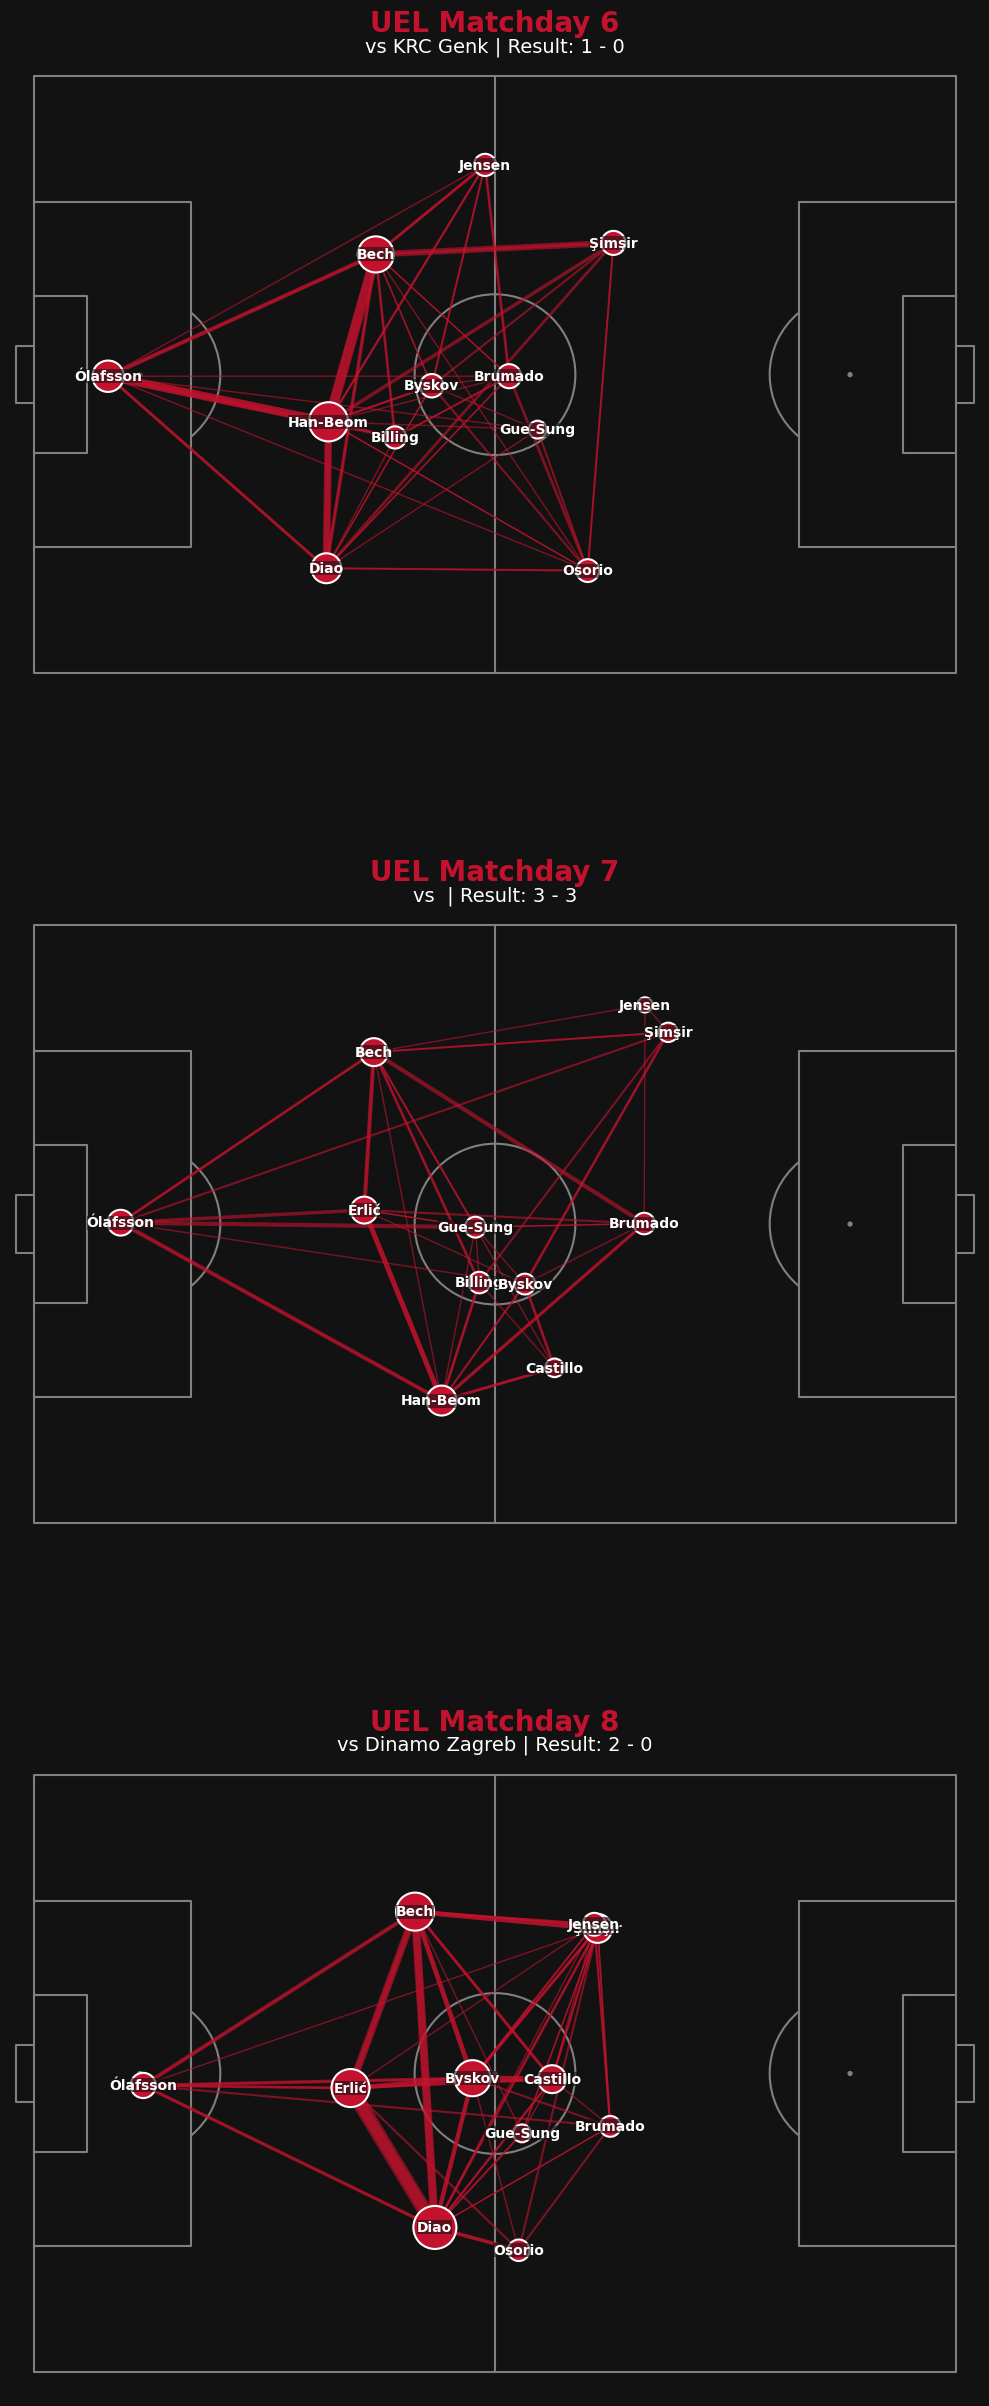

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os

path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'

# --- CONFIGURACIÓN MANUAL DE PARTIDOS ---
# Aquí definimos el orden y los títulos exactos que tú quieres
matches_config = [
    {
        "file": "FC Midtjylland vs KRC Genk.csv",
        "label": "UEL Matchday 6",
        "home_away": "Home" # Esto es visual, asumimos FCM local por el nombre del archivo
    },
    {
        "file": "SK Brann vs FC Midtjylland.csv",
        "label": "UEL Matchday 7",
        "home_away": "Away"
    },
    {
        "file": "FC Midtjylland vs Dinamo Zagreb.csv",
        "label": "UEL Matchday 8",
        "home_away": "Home"
    }
]

# Creamos la figura
fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(10, 26))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    nombre_archivo = config["file"]
    path_full = os.path.join(path_processed, nombre_archivo)

    # Verificar si existe
    if not os.path.exists(path_full):
        print(f"⚠️ Archivo no encontrado: {nombre_archivo}")
        continue

    # 1. Cargar Datos
    df_match = pd.read_csv(path_full)
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # --- CALCULADORA DE GOLES ---
    # Contamos eventos de Gol (typeId 16) que fueron exitosos (outcome 1)
    goals_fcm = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    # Formato del marcador (Siempre ponemos FCM primero para el análisis, o Local-Visitante)
    # Si quieres formato estricto Local-Visitante:
    if config["home_away"] == "Home":
        score_text = f"{goals_fcm} - {goals_opp}"
        team_label = "FCM (Home)"
    else:
        score_text = f"{goals_opp} - {goals_fcm}"
        team_label = "FCM (Away)"

    # 2. LÓGICA DE MINUTOS (Top 11)
    df_team = df_match[df_match['contestantId'] == fcm_id].copy()
    player_minutes = df_team.groupby('playerName')['timeMin'].agg(['min', 'max'])
    player_minutes['minutes_played'] = player_minutes['max'] - player_minutes['min']
    top_11_minutes = player_minutes.sort_values('minutes_played', ascending=False).head(11).index.tolist()

    # 3. FILTRAR PASES
    passes = df_team[
        (df_team['typeId'] == 1) &
        (df_team['outcome'] == 1) &
        (df_team['playerName'].isin(top_11_minutes))
    ].copy()

    avg_locs = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
    avg_locs.columns = ['x', 'y', 'count']

    passes['receptor'] = passes['playerName'].shift(-1)
    pass_net = passes.groupby(['playerName', 'receptor']).size().reset_index(name='pass_count')

    # --- DIBUJO ---
    # line_color='#808080' hace las líneas más claras
    pitch = Pitch(pitch_type='opta', pitch_color='#121212', line_color='#808080',
                  goal_type='box', linewidth=1.5)
    pitch.draw(ax=axs[i])

    # Líneas de pase
    for _, row in pass_net.iterrows():
        if row['pass_count'] > 1:
            if row['receptor'] in top_11_minutes and row['playerName'] in top_11_minutes:
                p1 = avg_locs.loc[row['playerName']]
                p2 = avg_locs.loc[row['receptor']]
                width = row['pass_count'] / 2
                pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=width,
                            color='#C4122E', alpha=0.6, zorder=1, ax=axs[i]) # Rojo FCM

    # Nodos
    if not avg_locs.empty:
        pitch.scatter(avg_locs.x, avg_locs.y, s=avg_locs['count']*15,
                      color='#C4122E', edgecolors='white', linewidth=1.5, zorder=2, ax=axs[i])

        for index, row in avg_locs.iterrows():
            pitch.annotate(index.split(' ')[-1], xy=(row.x, row.y), c='white',
                           va='center', ha='center', size=10, weight='bold',
                           bbox=dict(facecolor='#121212', edgecolor='none', alpha=0.6, pad=0),
                           ax=axs[i])

    # --- TÍTULOS Y MARCADOR ---
    # Título Principal (Jornada)
    axs[i].set_title(f"{config['label']}", color='#C4122E', size=20, weight='bold', pad=15)

    # Subtítulo (Resultado y Rival)
    opponent_name = nombre_archivo.replace('FC Midtjylland', '').replace('SK Brann', '').replace('vs', '').replace('.csv', '').strip()
    axs[i].text(50, 105, f"vs {opponent_name} | Result: {score_text}",
                ha='center', va='center', color='white', size=14)

plt.tight_layout()
plt.show()

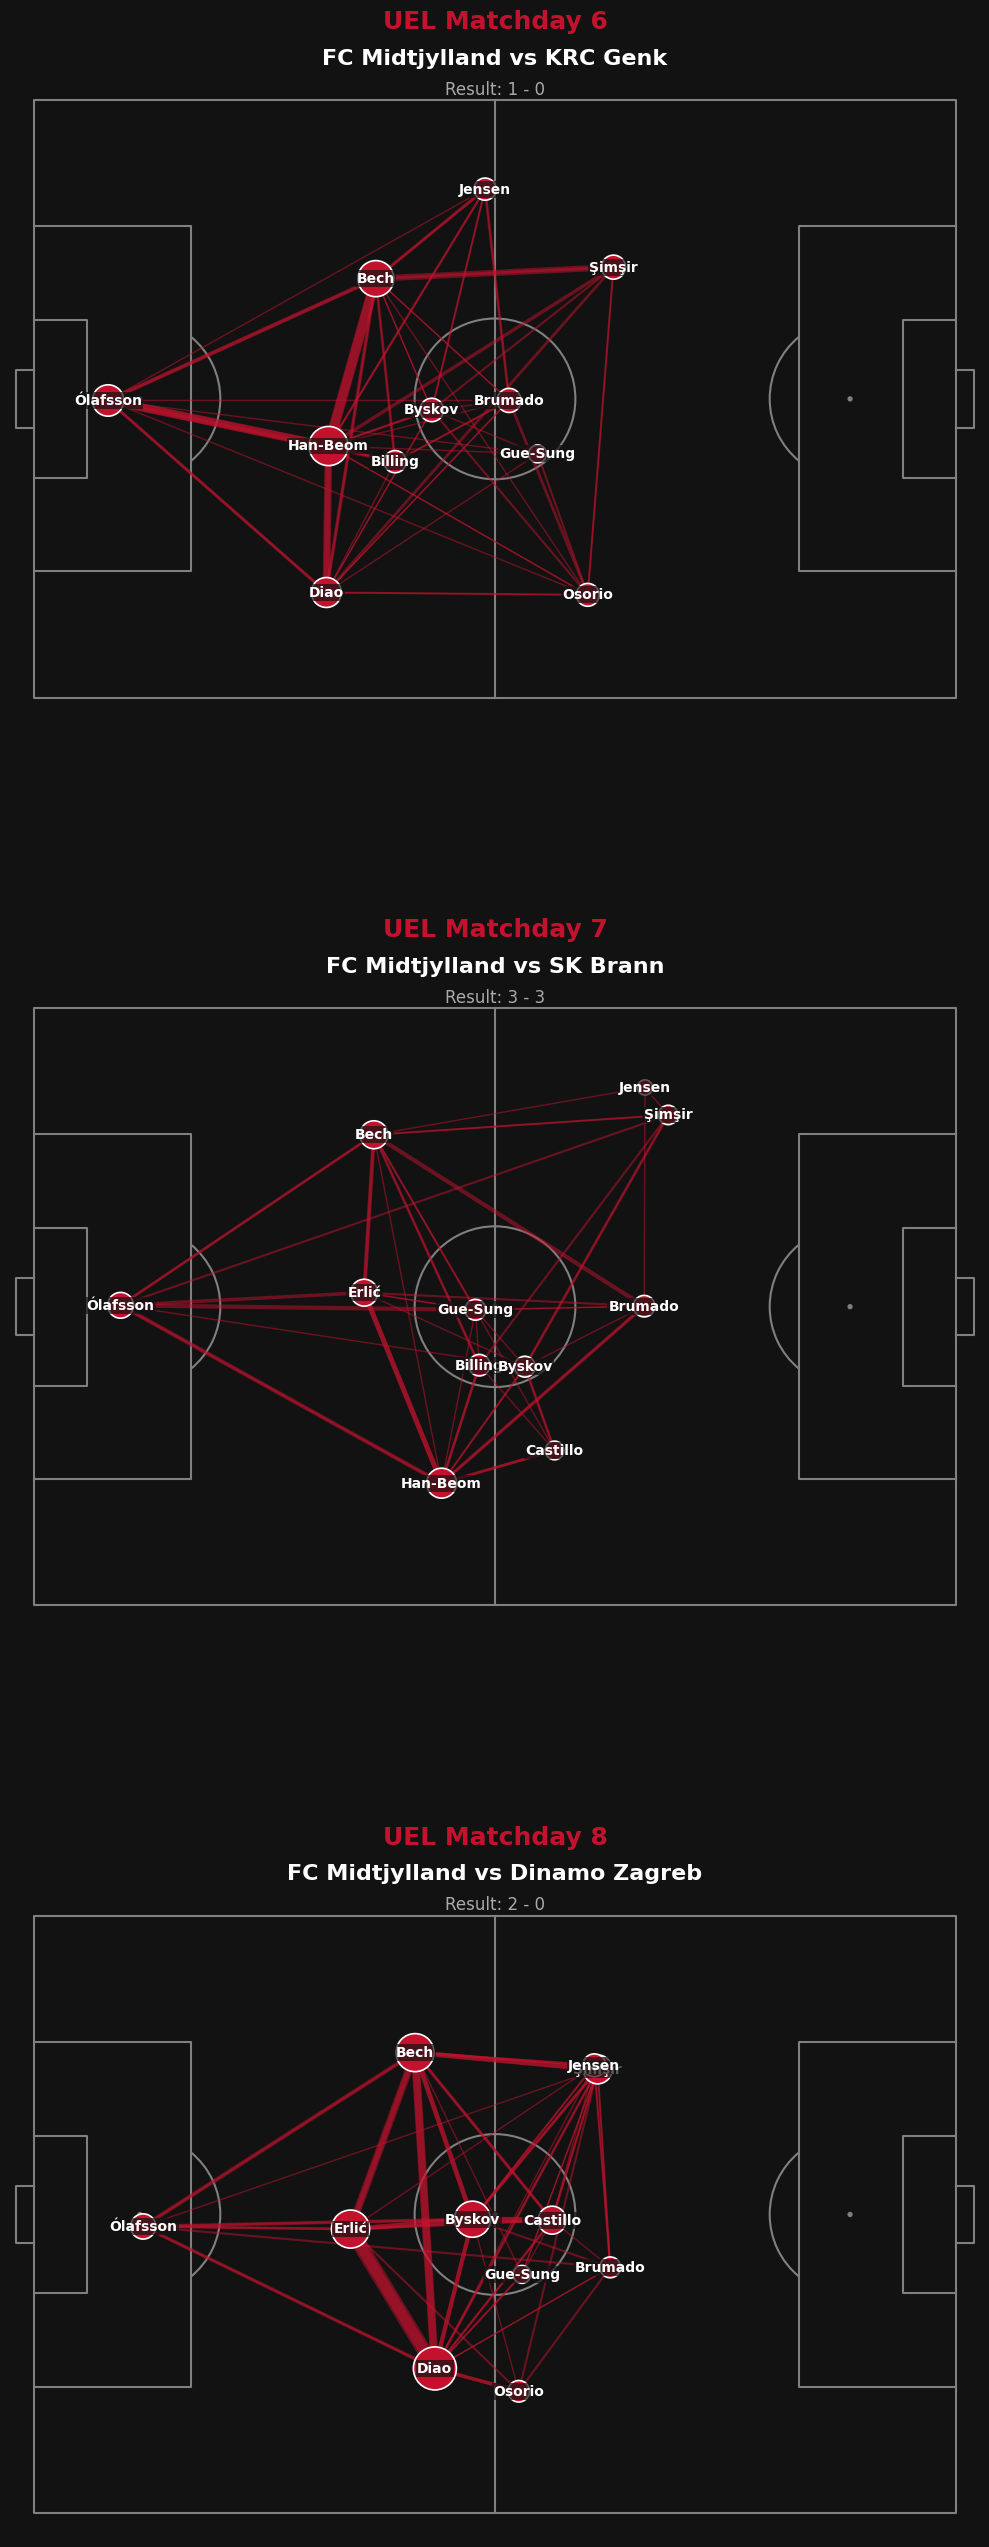

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os

path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'

# --- CONFIGURACIÓN DE PARTIDOS ---
matches_config = [
    {"file": "FC Midtjylland vs KRC Genk.csv", "label": "UEL Matchday 6", "opponent": "KRC Genk"},
    {"file": "SK Brann vs FC Midtjylland.csv", "label": "UEL Matchday 7", "opponent": "SK Brann"},
    {"file": "FC Midtjylland vs Dinamo Zagreb.csv", "label": "UEL Matchday 8", "opponent": "Dinamo Zagreb"}
]

fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(10, 28))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    path_full = os.path.join(path_processed, config["file"])
    if not os.path.exists(path_full): continue

    # 1. Cargar Datos y Detectar ID
    df_match = pd.read_csv(path_full)
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # 2. Marcador (Goles FCM vs Rival)
    goals_fcm = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])
    score_text = f"Result: {goals_fcm} - {goals_opp}" if "Genk" in config["opponent"] or "Zagreb" in config["opponent"] else f"Result: {goals_opp} - {goals_fcm}"

    # 3. Top 11 por Minutos
    df_team = df_match[df_match['contestantId'] == fcm_id].copy()
    player_minutes = df_team.groupby('playerName')['timeMin'].agg(['min', 'max'])
    player_minutes['played'] = player_minutes['max'] - player_minutes['min']
    top_11 = player_minutes.sort_values('played', ascending=False).head(11).index.tolist()

    # 4. Procesar Pases
    passes = df_team[(df_team['typeId'] == 1) & (df_team['outcome'] == 1) & (df_team['playerName'].isin(top_11))].copy()
    avg_locs = passes.groupby('playerName').agg({'x': ['mean'], 'y': ['mean', 'count']})
    avg_locs.columns = ['x', 'y', 'count']
    passes['receptor'] = passes['playerName'].shift(-1)
    pass_net = passes.groupby(['playerName', 'receptor']).size().reset_index(name='count')

    # --- DIBUJO ---
    pitch = Pitch(pitch_type='opta', pitch_color='#121212', line_color='#808080', goal_type='box', linewidth=1.5)
    pitch.draw(ax=axs[i])

    # Líneas de pases
    for _, row in pass_net.iterrows():
        if row['count'] > 1 and row['receptor'] in top_11 and row['playerName'] in top_11:
            p1, p2 = avg_locs.loc[row['playerName']], avg_locs.loc[row['receptor']]
            pitch.lines(p1.x, p1.y, p2.x, p2.y, lw=row['count']/2, color='#C4122E', alpha=0.5, zorder=1, ax=axs[i])

    # Nodos y Nombres con fondo
    pitch.scatter(avg_locs.x, avg_locs.y, s=avg_locs['count']*15, color='#C4122E', edgecolors='white', linewidth=1.2, zorder=2, ax=axs[i])
    for index, row in avg_locs.iterrows():
        pitch.annotate(index.split(' ')[-1], xy=(row.x, row.y), c='white', va='center', ha='center', size=10, weight='bold',
                       bbox=dict(facecolor='#121212', edgecolor='none', alpha=0.7, pad=1), ax=axs[i])

    # --- TÍTULOS ESTRUCTURADOS ---
    axs[i].text(50, 112, f"{config['label']}", color='#C4122E', size=18, weight='bold', ha='center')
    axs[i].text(50, 106, f"FC Midtjylland vs {config['opponent']}", color='white', size=16, weight='bold', ha='center')
    axs[i].text(50, 101, f"{score_text}", color='#aaaaaa', size=12, ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# Definimos el nombre y la ruta de guardado
output_path = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed/FCM_Passing_Network_Comparison.png'

# Guardamos la figura
# dpi=300: Calidad de impresión profesional
# bbox_inches='tight': Elimina los bordes blancos innecesarios alrededor de la imagen
fig.savefig(output_path, dpi=300, bbox_inches='tight', facecolor='#121212')

print(f"✅ ¡Visualización guardada con éxito en: {output_path}")

✅ ¡Visualización guardada con éxito en: /content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed/FCM_Passing_Network_Comparison.png


In [ ]:
# Definimos las rutas para ambos formatos
output_pdf = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed/FCM_Passing_Network_Final.pdf'
output_png = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed/FCM_Passing_Network_Final.png'

# Guardar en PDF (Calidad infinita para el TFM)
fig.savefig(output_pdf,
            bbox_inches='tight',
            facecolor='#121212',
            transparent=False)

# Guardar en PNG (Alta resolución para presentaciones o compartir)
fig.savefig(output_png,
            dpi=300,
            bbox_inches='tight',
            facecolor='#121212')

print(f"✅ ¡Archivos guardados!")
print(f"1. PDF (Vectorial): {output_pdf}")
print(f"2. PNG (300 DPI): {output_png}")

✅ ¡Archivos guardados!
1. PDF (Vectorial): /content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed/FCM_Passing_Network_Final.pdf
2. PNG (300 DPI): /content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed/FCM_Passing_Network_Final.png


In [ ]:
import pandas as pd
import ast
import os

def get_xg_value(qualifiers_str):
    try:
        # Convertimos el string de la columna a una lista real de Python
        quals = ast.literal_eval(qualifiers_str)
        for q in quals:
            if q.get('qualifierId') == 321: # ID de Opta para xG
                return float(q.get('value'))
    except:
        return 0.05 # Valor por defecto bajo si no se encuentra
    return 0.05

path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'

# --- CONFIGURACIÓN DE PARTIDOS (Copiado de N99mRqqP1DbY para que esté disponible) ---
matches_config = [
    {"file": "FC Midtjylland vs KRC Genk.csv", "label": "UEL Matchday 6", "opponent": "KRC Genk"},
    {"file": "SK Brann vs FC Midtjylland.csv", "label": "UEL Matchday 7", "opponent": "SK Brann"},
    {"file": "FC Midtjylland vs Dinamo Zagreb.csv", "label": "UEL Matchday 8", "opponent": "Dinamo Zagreb"}
]

# --- PROCESAMOS LOS TIROS CON xG ---
for config in matches_config:
    path_full = os.path.join(path_processed, config["file"])

    # Verificar si el archivo existe antes de intentar leerlo
    if not os.path.exists(path_full):
        print(f"⚠️ Archivo no encontrado: {config['file']}. Saltando este partido.")
        continue

    df_match = pd.read_csv(path_full)

    # Auto-detectar fcm_id para cada archivo (similar a N99mRqqP1DbY)
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # 1. Filtramos solo tiros (typeId 13, 14, 15, 16...)
    # Opta usa varios IDs para intentos, goles, palos, etc.
    shot_types = [13, 14, 15, 16]
    df_shots = df_match[(df_match['contestantId'] == fcm_id) &
                        (df_match['typeId'].isin(shot_types))].copy()

    # 2. Extraemos el xG usando nuestra función
    df_shots['xG'] = df_shots['qualifiers'].apply(get_xg_value)

    # 3. Guardamos o imprimimos para verificar
    total_xg = df_shots['xG'].sum()
    print(f"{config['label']}: {len(df_shots)} tiros | xG Total: {total_xg:.2f}")

KeyError: 'qualifiers'

Esto dio error porque Colab se desconceto (Tiempo inactivo)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import pandas as pd
import ast

# Definimos de nuevo las rutas
path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'

# Refrescamos la lista de partidos
matches_config = [
    {"file": "FC Midtjylland vs KRC Genk.csv", "label": "UEL Matchday 6", "opponent": "KRC Genk"},
    {"file": "SK Brann vs FC Midtjylland.csv", "label": "UEL Matchday 7", "opponent": "SK Brann"},
    {"file": "FC Midtjylland vs Dinamo Zagreb.csv", "label": "UEL Matchday 8", "opponent": "Dinamo Zagreb"}
]

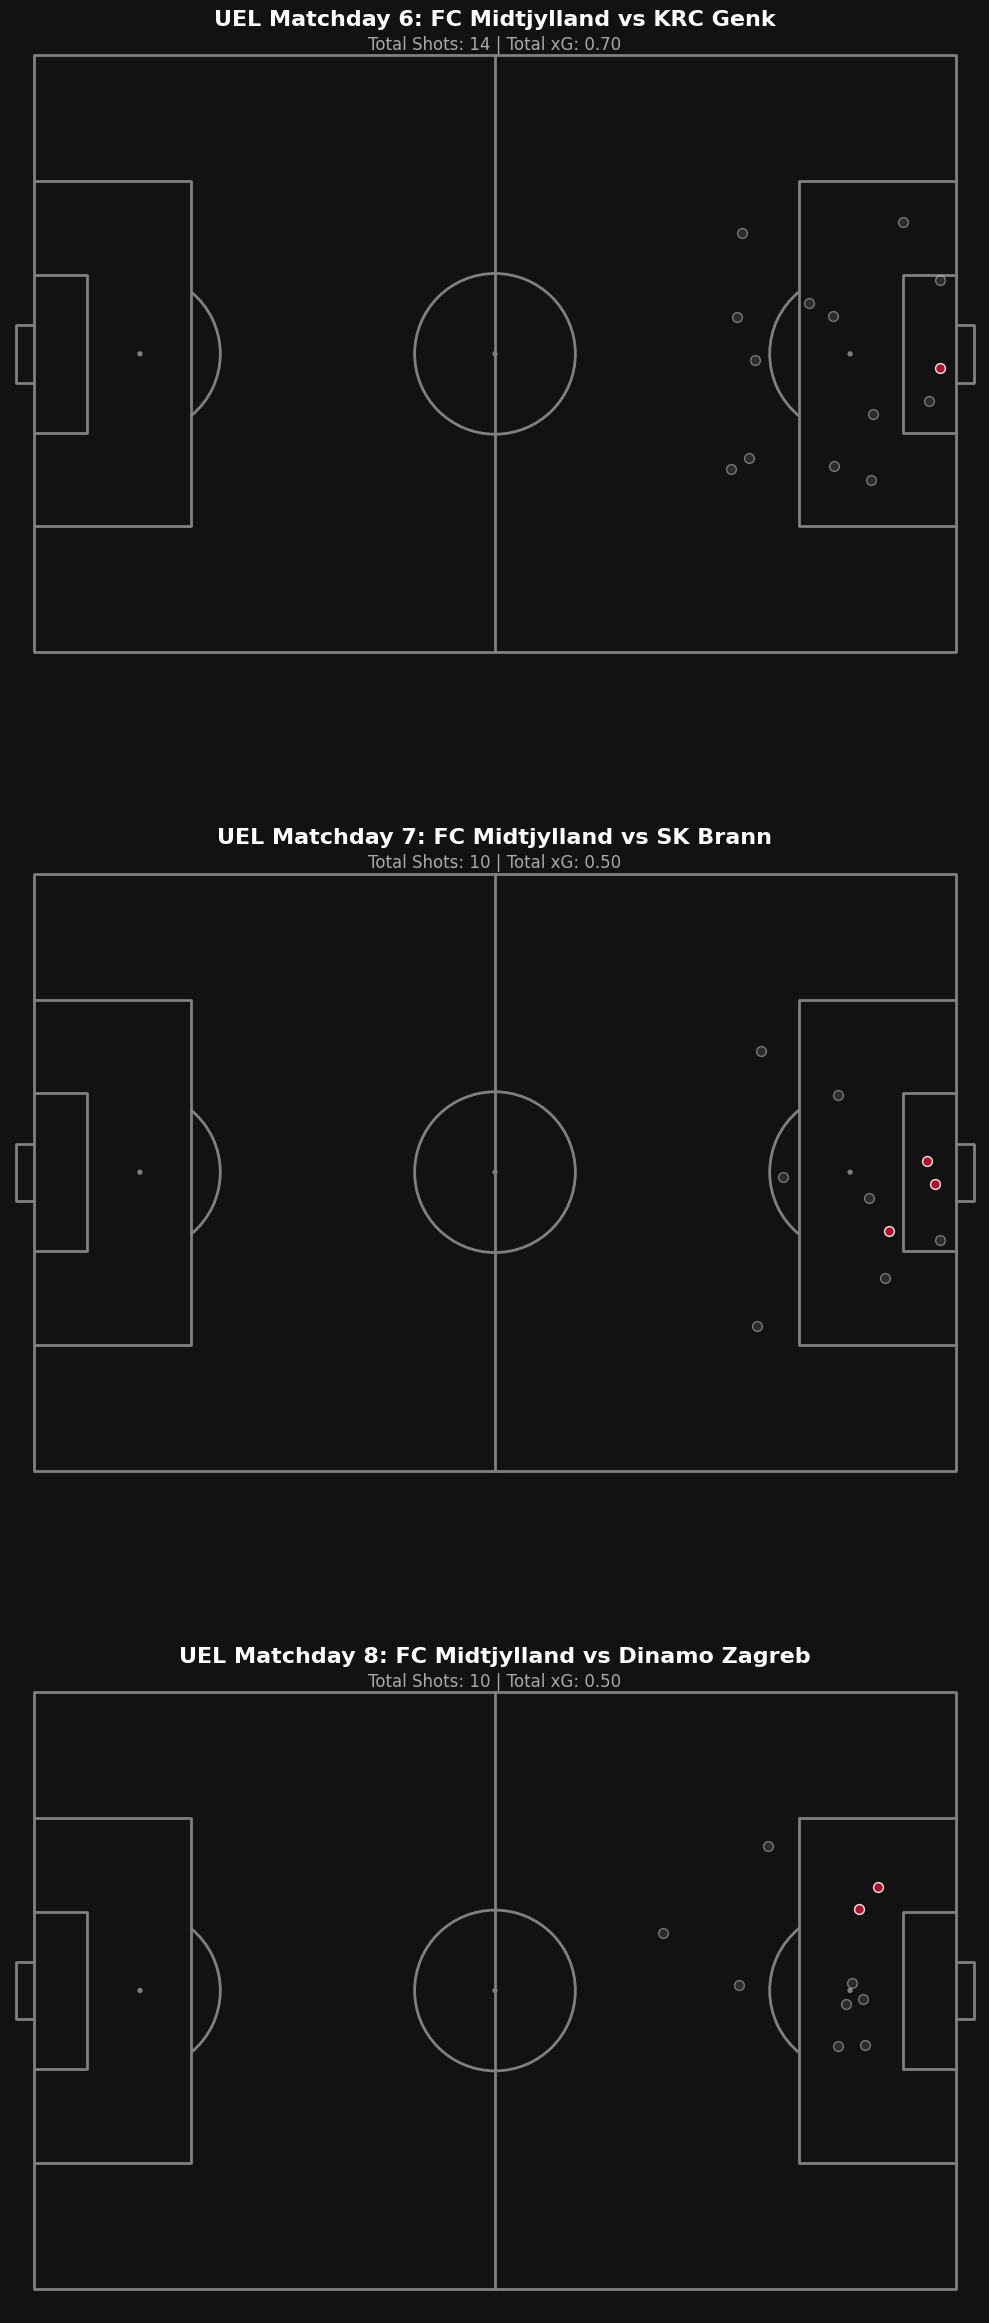

In [ ]:
!pip install mplsoccer
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import numpy as np
import pandas as pd
import os
import ast

# Función para extraer el valor de xG del string de qualifiers
def get_xg(qualifiers_str):
    try:
        # Ensure qualifiers_str is treated as a list-like string
        quals = ast.literal_eval(str(qualifiers_str)) # Convert to string first to handle non-string inputs
        for q in quals:
            if q.get('qualifierId') == 321:
                return float(q.get('value'))
    except:
        pass
    return 0.05 # Valor por defecto si no tiene xG asignado

fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(10, 25))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    path_full = os.path.join(path_processed, config["file"])
    # Add a check for file existence, similar to H0ePyz1vmn7f
    if not os.path.exists(path_full):
        print(f"⚠️ Archivo no encontrado: {config['file']}. Saltando este partido.")
        continue

    df_match = pd.read_csv(path_full)

    # Detectamos el ID del Midtjylland
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # Filtramos tiros: typeId 13 (intento), 14 (gol), 15 (poste)
    df_shots = df_match[(df_match['contestantId'] == fcm_id) &
                        (df_match['typeId'].isin([13, 14, 15, 16]))].copy()

    # Extraemos xG, usando la columna 'qualifier' (singular)
    # Check if 'qualifier' column exists before applying function
    if 'qualifier' in df_shots.columns:
        df_shots['xG'] = df_shots['qualifier'].apply(get_xg)
    else:
        df_shots['xG'] = 0.05 # Default xG if column is missing
        print(f"Advertencia: 'qualifier' column no encontrada en {config['file']}. xG por defecto asignado.")

    # Dibujamos el campo
    pitch = Pitch(pitch_type='opta', pitch_color='#121212', line_color='#808080', goal_type='box')
    pitch.draw(ax=axs[i])

    # Pintamos los tiros
    # Los Goles (typeId 16) en un color y los fallos en otro
    for _, shot in df_shots.iterrows():
        is_goal = shot['typeId'] == 16
        color = '#C4122E' if is_goal else '#555555' # Rojo FCM para gol, gris para fallo
        alpha = 0.9 if is_goal else 0.4

        # El tamaño del círculo depende del xG (multiplicamos por 1000 para que se vea)
        pitch.scatter(shot.x, shot.y, s=shot['xG'] * 1000,
                      edgecolors='white', c=color, alpha=alpha, ax=axs[i])

    # Títulos
    total_xg = df_shots['xG'].sum()
    axs[i].text(50, 105, f"{config['label']}: FC Midtjylland vs {config['opponent']}",
                color='white', size=16, weight='bold', ha='center')
    axs[i].text(50, 101, f"Total Shots: {len(df_shots)} | Total xG: {total_xg:.2f}",
                color='#aaaaaa', size=12, ha='center')

plt.tight_layout()
plt.show()

In [ ]:
# Diagnóstico rápido para ver si el xG existe en el texto
for config in matches_config:
    df_test = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_test.groupby('contestantId').size().idxmax()

    # Buscamos solo tiros
    shots_test = df_test[(df_test['contestantId'] == fcm_id) & (df_test['typeId'].isin([13, 14, 15, 16]))]

    # Miramos el primer tiro que encontremos
    if not shots_test.empty:
        sample_qual = shots_test['qualifier'].iloc[0] # A veces es 'qualifier' sin 's'
        print(f"--- Partido: {config['opponent']} ---")
        print(f"Texto del primer tiro: {sample_qual[:200]}...") # Solo los primeros 200 caracteres
        if '321' in str(sample_qual):
            print("✅ El ID 321 (xG) SÍ está presente.")
        else:
            print("❌ El ID 321 (xG) NO aparece en este archivo.")

--- Partido: KRC Genk ---
Texto del primer tiro: [{'id': 6104383693, 'qualifierId': 23}, {'id': 6104848139, 'qualifierId': 215}, {'id': 6104384215, 'qualifierId': 233, 'value': '7'}, {'id': 6104383697, 'qualifierId': 72}, {'id': 6104382201, 'qualifi...
❌ El ID 321 (xG) NO aparece en este archivo.
--- Partido: SK Brann ---
Texto del primer tiro: [{'id': 6157395455, 'qualifierId': 29}, {'id': 6157395467, 'qualifierId': 214}, {'id': 6157394561, 'qualifierId': 328}, {'id': 6157896471, 'qualifierId': 395, 'value': '99.3'}, {'id': 6157395469, 'qua...
❌ El ID 321 (xG) NO aparece en este archivo.
--- Partido: Dinamo Zagreb ---
Texto del primer tiro: [{'id': 6170794467, 'qualifierId': 328}, {'id': 6170795069, 'qualifierId': 76}, {'id': 6170794461, 'qualifierId': 102, 'value': '54.2'}, {'id': 6170790531, 'qualifierId': 56, 'value': 'Center'}, {'id'...
❌ El ID 321 (xG) NO aparece en este archivo.


In [ ]:
import numpy as np

def calculate_estimated_xg(x, y, is_goal):
    # En Opta, la portería está en x=100, y=50
    # Calculamos distancia euclidiana a la portería
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)

    # Un tiro desde el punto de penalti (distancia ~12) suele ser 0.12 - 0.15
    # Un tiro desde fuera del área (distancia > 16) suele ser < 0.05
    # Esta fórmula es una aproximación estadística estándar
    estimado = np.exp(-0.15 * distancia)

    # Si es gol, el xG no cambia (el xG es la probabilidad PREVIA al tiro)
    return round(estimado, 3)

# --- AHORA APLICAMOS ESTO AL GRÁFICO ---
for i, config in enumerate(matches_config):
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # Filtramos tiros (IDs: 13, 14, 15 y el 16 que es gol)
    df_shots = df_match[(df_match['contestantId'] == fcm_id) &
                        (df_match['typeId'].isin([13, 14, 15, 16]))].copy()

    # Calculamos nuestro propio xG basado en la posición real
    df_shots['xG'] = df_shots.apply(lambda row: calculate_estimated_xg(row.x, row.y, row.typeId == 16), axis=1)

    # ... (Resto del código de dibujo de ayer) ...

    total_xg = df_shots['xG'].sum()
    print(f"{config['label']}: {len(df_shots)} tiros | xG Estimado: {total_xg:.2f}")

UEL Matchday 6: 14 tiros | xG Estimado: 1.58
UEL Matchday 7: 10 tiros | xG Estimado: 1.96
UEL Matchday 8: 10 tiros | xG Estimado: 0.96


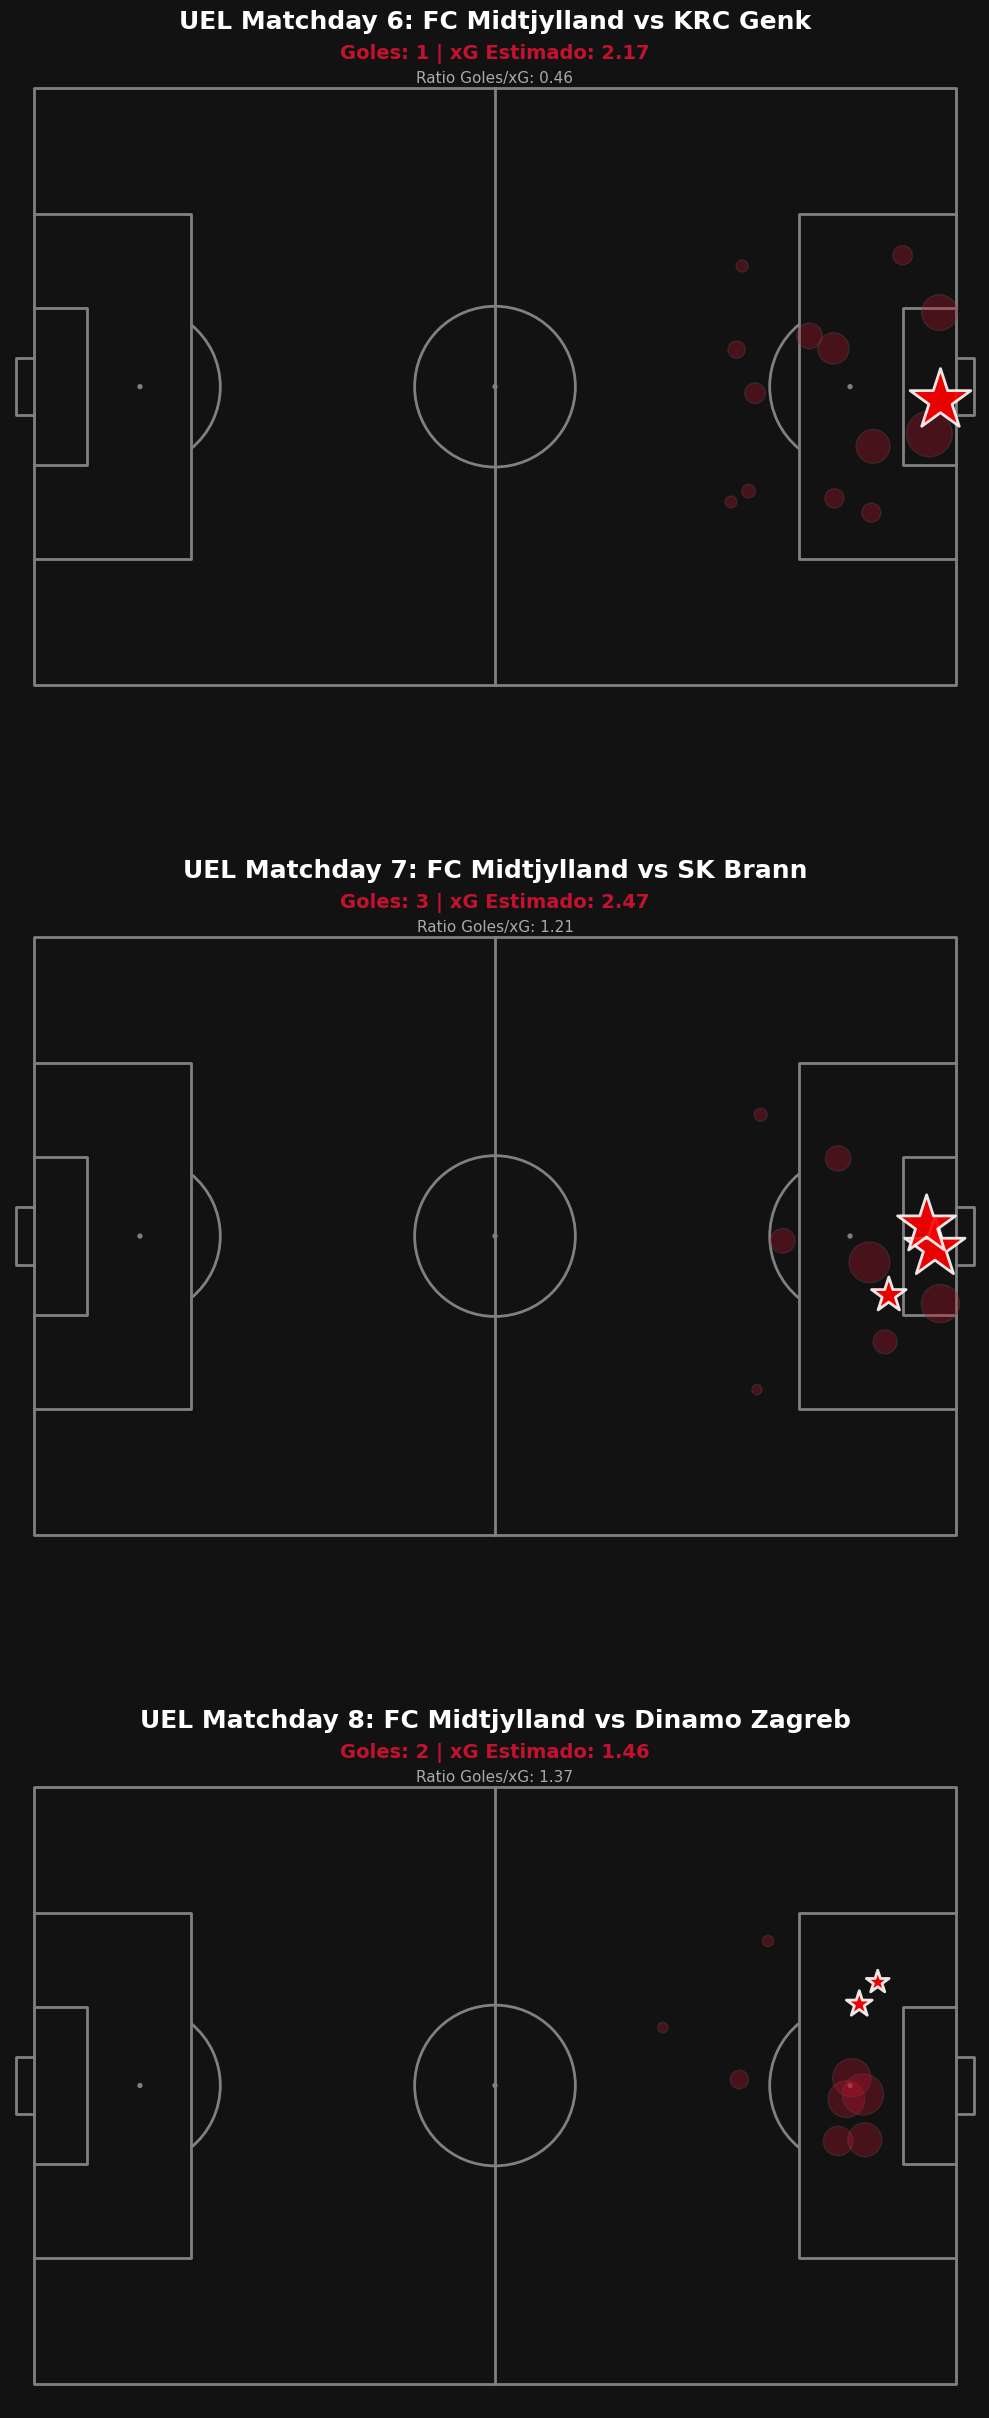

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os
import numpy as np

# 1. Función de Cálculo de xG Geométrico
def calculate_estimated_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    # Fórmula ajustada para dar valores realistas (Penalti ~0.76, Cercano ~0.3, Lejos <0.05)
    estimado = np.exp(-0.12 * distancia)
    return round(estimado, 3)

fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(10, 26))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    # Cargar datos
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # Filtramos tiros (typeId 13: fuera, 14: al palo, 15: parada, 16: GOL)
    df_shots = df_match[(df_match['contestantId'] == fcm_id) &
                        (df_match['typeId'].isin([13, 14, 15, 16]))].copy()

    # Aplicamos nuestro xG casero
    df_shots['xG'] = df_shots.apply(lambda row: calculate_estimated_xg(row.x, row.y), axis=1)

    # Dibujar campo
    pitch = Pitch(pitch_type='opta', pitch_color='#121212', line_color='#808080', goal_type='box')
    pitch.draw(ax=axs[i])

    # Separamos Goles de Fallos para pintarlos distinto
    df_goals = df_shots[df_shots['typeId'] == 16]
    df_misses = df_shots[df_shots['typeId'] != 16]

    # Pintar FALLOS (Gris/Rojo apagado con transparencia)
    pitch.scatter(df_misses.x, df_misses.y, s=df_misses['xG'] * 3000,
                  edgecolors='#555555', c='#C4122E', alpha=0.3, ax=axs[i])

    # Pintar GOLES (Rojo brillante con borde blanco y más opaco)
    pitch.scatter(df_goals.x, df_goals.y, s=df_goals['xG'] * 3000,
                  edgecolors='white', linewidth=2, c='#FF0000', alpha=0.9, marker='*', ax=axs[i], label='Gol')

    # Títulos y Estadísticas
    total_xg = df_shots['xG'].sum()
    goles_reales = len(df_goals)

    axs[i].text(50, 110, f"{config['label']}: FC Midtjylland vs {config['opponent']}",
                color='white', size=18, weight='bold', ha='center')

    # Subtítulo con el "insight" analítico
    diff = goles_reales - total_xg
    performance = "Sobrerendimiento" if diff > 0 else "Infrarendimiento"

    axs[i].text(50, 105, f"Goles: {goles_reales} | xG Estimado: {total_xg:.2f}",
                color='#C4122E', size=14, weight='bold', ha='center')

    axs[i].text(50, 101, f"Ratio Goles/xG: {goles_reales/total_xg:.2f}",
                color='#aaaaaa', size=11, ha='center')

plt.tight_layout()
plt.show()

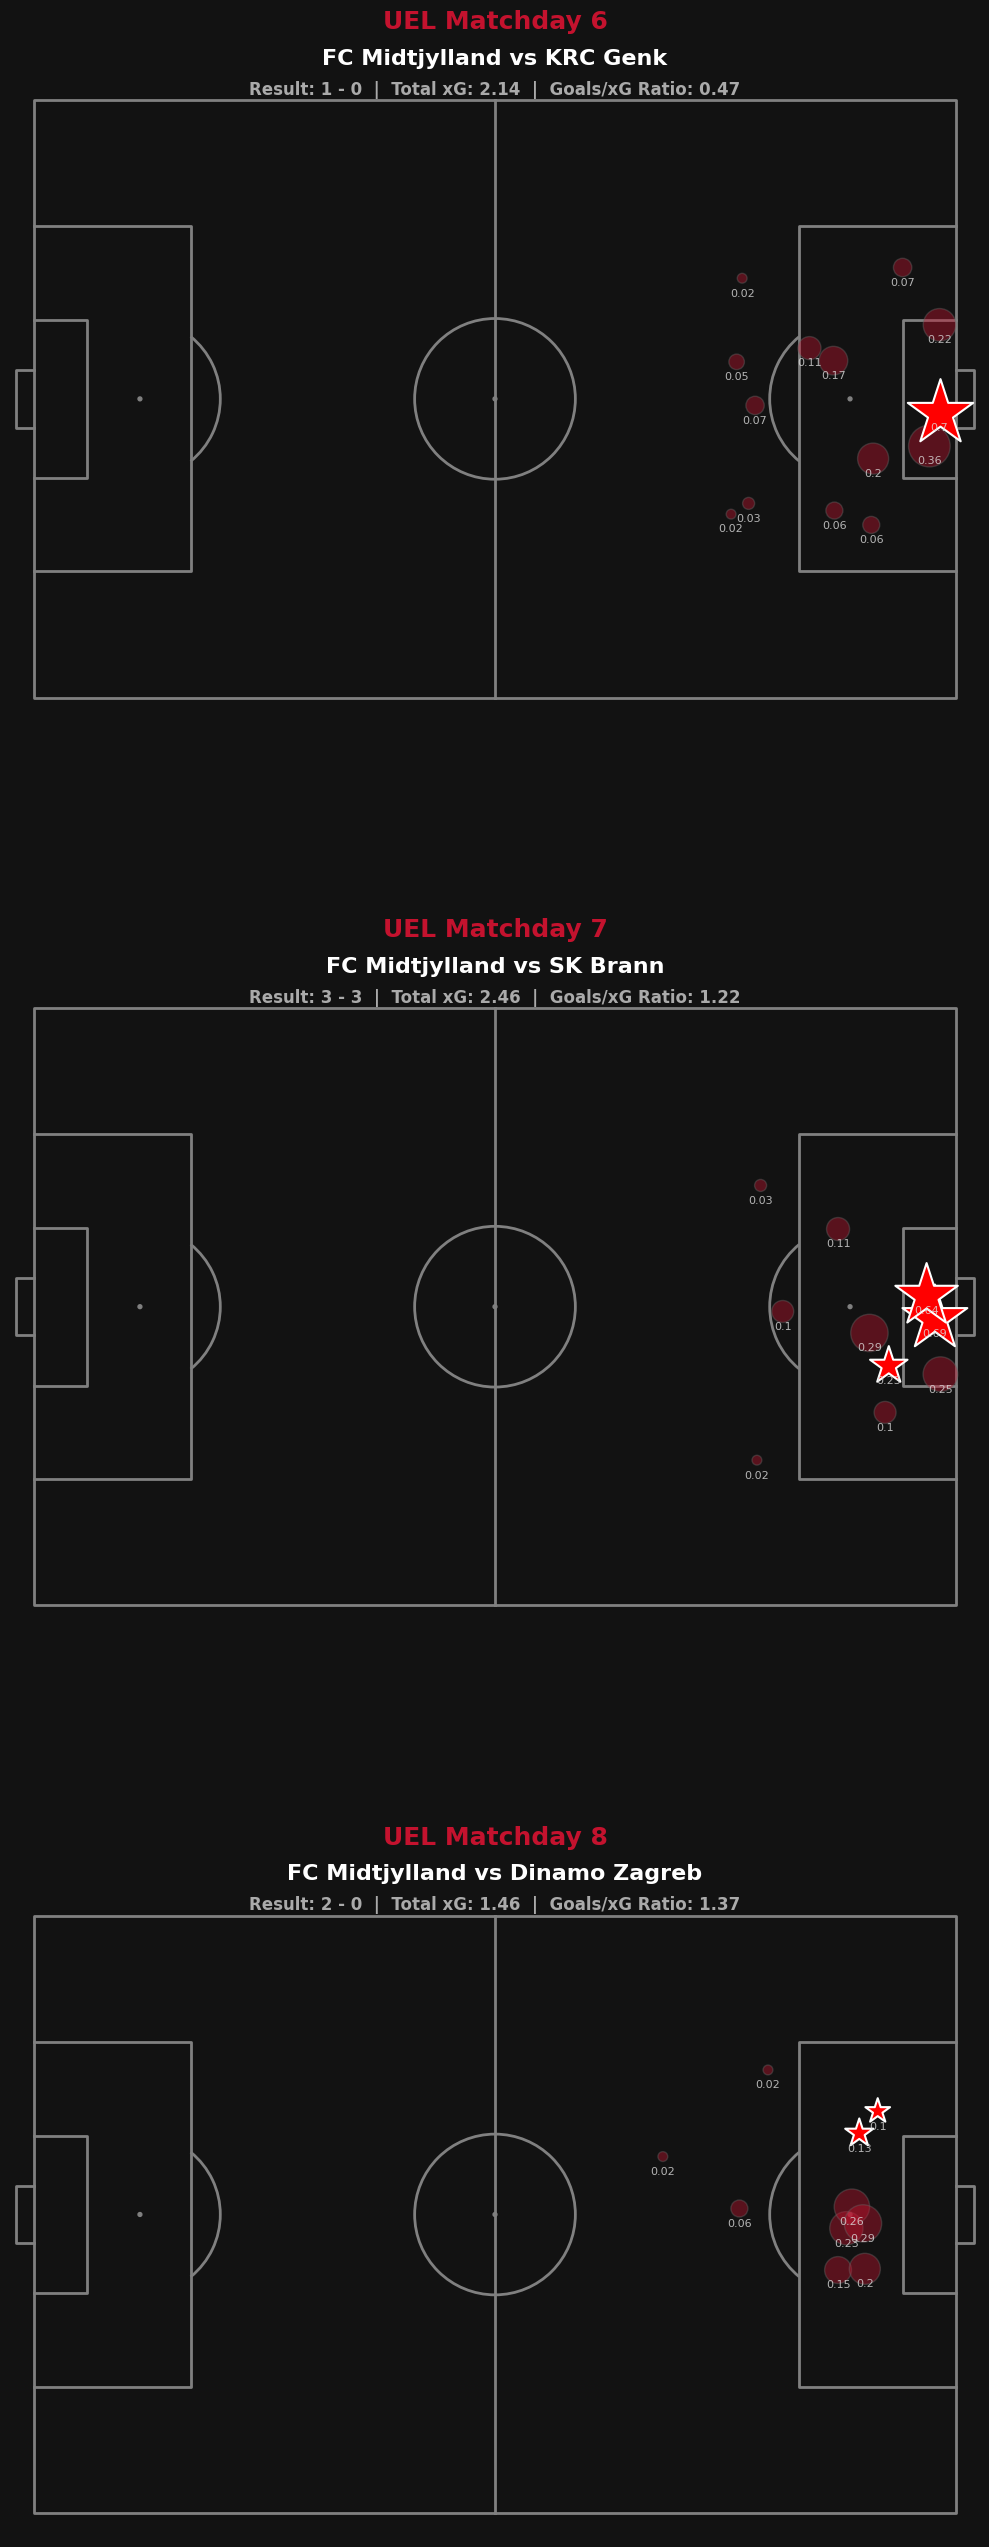

In [ ]:
import matplotlib.pyplot as plt
from mplsoccer import Pitch
import pandas as pd
import os
import numpy as np

# Definir rutas y configuración
path_processed = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed'

matches_config = [
    {"file": "FC Midtjylland vs KRC Genk.csv", "label": "UEL Matchday 6", "opponent": "KRC Genk"},
    {"file": "SK Brann vs FC Midtjylland.csv", "label": "UEL Matchday 7", "opponent": "SK Brann"},
    {"file": "FC Midtjylland vs Dinamo Zagreb.csv", "label": "UEL Matchday 8", "opponent": "Dinamo Zagreb"}
]

# Función de xG Estimado (Modelo Geométrico)
def calculate_estimated_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    estimado = np.exp(-0.12 * distancia)
    return round(estimado, 2) # Redondeamos a 2 decimales para la etiqueta

fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(10, 28))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    # Cargar datos
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    # --- CALCULAR MARCADOR EXACTO ---
    goals_fcm = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    # Lógica para mostrar Local-Visitante correctamente según el nombre del archivo
    if "vs FC Midtjylland" in config["file"]: # FCM es visitante
        score_text = f"Result: {goals_opp} - {goals_fcm}"
    else: # FCM es local
        score_text = f"Result: {goals_fcm} - {goals_opp}"

    # --- PROCESAR TIROS ---
    df_shots = df_match[(df_match['contestantId'] == fcm_id) &
                        (df_match['typeId'].isin([13, 14, 15, 16]))].copy()

    # Calcular xG
    df_shots['xG'] = df_shots.apply(lambda row: calculate_estimated_xg(row.x, row.y), axis=1)

    # --- DIBUJAR CAMPO ---
    pitch = Pitch(pitch_type='opta', pitch_color='#121212', line_color='#808080', goal_type='box')
    pitch.draw(ax=axs[i])

    # Separar Goles y Fallos
    df_goals = df_shots[df_shots['typeId'] == 16]
    df_misses = df_shots[df_shots['typeId'] != 16]

    # Pintar FALLOS (Círculos)
    pitch.scatter(df_misses.x, df_misses.y, s=df_misses['xG'] * 2500,
                  edgecolors='#666666', c='#C4122E', alpha=0.4, ax=axs[i])

    # Pintar GOLES (Estrellas brillantes)
    pitch.scatter(df_goals.x, df_goals.y, s=df_goals['xG'] * 3500,
                  edgecolors='white', linewidth=1.5, c='#FF0000', alpha=1, marker='*', ax=axs[i])

    # --- ETIQUETAS DE xG INDIVIDUAL ---
    for _, shot in df_shots.iterrows():
        # Ajustamos la posición del texto para que no tape el punto (y - 2 unidades)
        pitch.annotate(f"{shot['xG']}", (shot.x, shot.y - 2.5),
                       ax=axs[i], ha='center', va='center', color='#dddddd', fontsize=8, alpha=0.8)

    # --- ESTADÍSTICAS DEL PARTIDO ---
    total_xg = df_shots['xG'].sum()
    ratio = goals_fcm / total_xg if total_xg > 0 else 0

    # Título Principal
    axs[i].text(50, 112, f"{config['label']}", color='#C4122E', size=18, weight='bold', ha='center')
    axs[i].text(50, 106, f"FC Midtjylland vs {config['opponent']}", color='white', size=16, weight='bold', ha='center')

    # Línea de Datos (Result | Total xG | Ratio)
    stats_line = f"{score_text}  |  Total xG: {total_xg:.2f}  |  Goals/xG Ratio: {ratio:.2f}"
    axs[i].text(50, 101, stats_line, color='#aaaaaa', size=12, ha='center', weight='bold')

plt.tight_layout()
fig_shots = fig
plt.show()

Version final. Exportar.


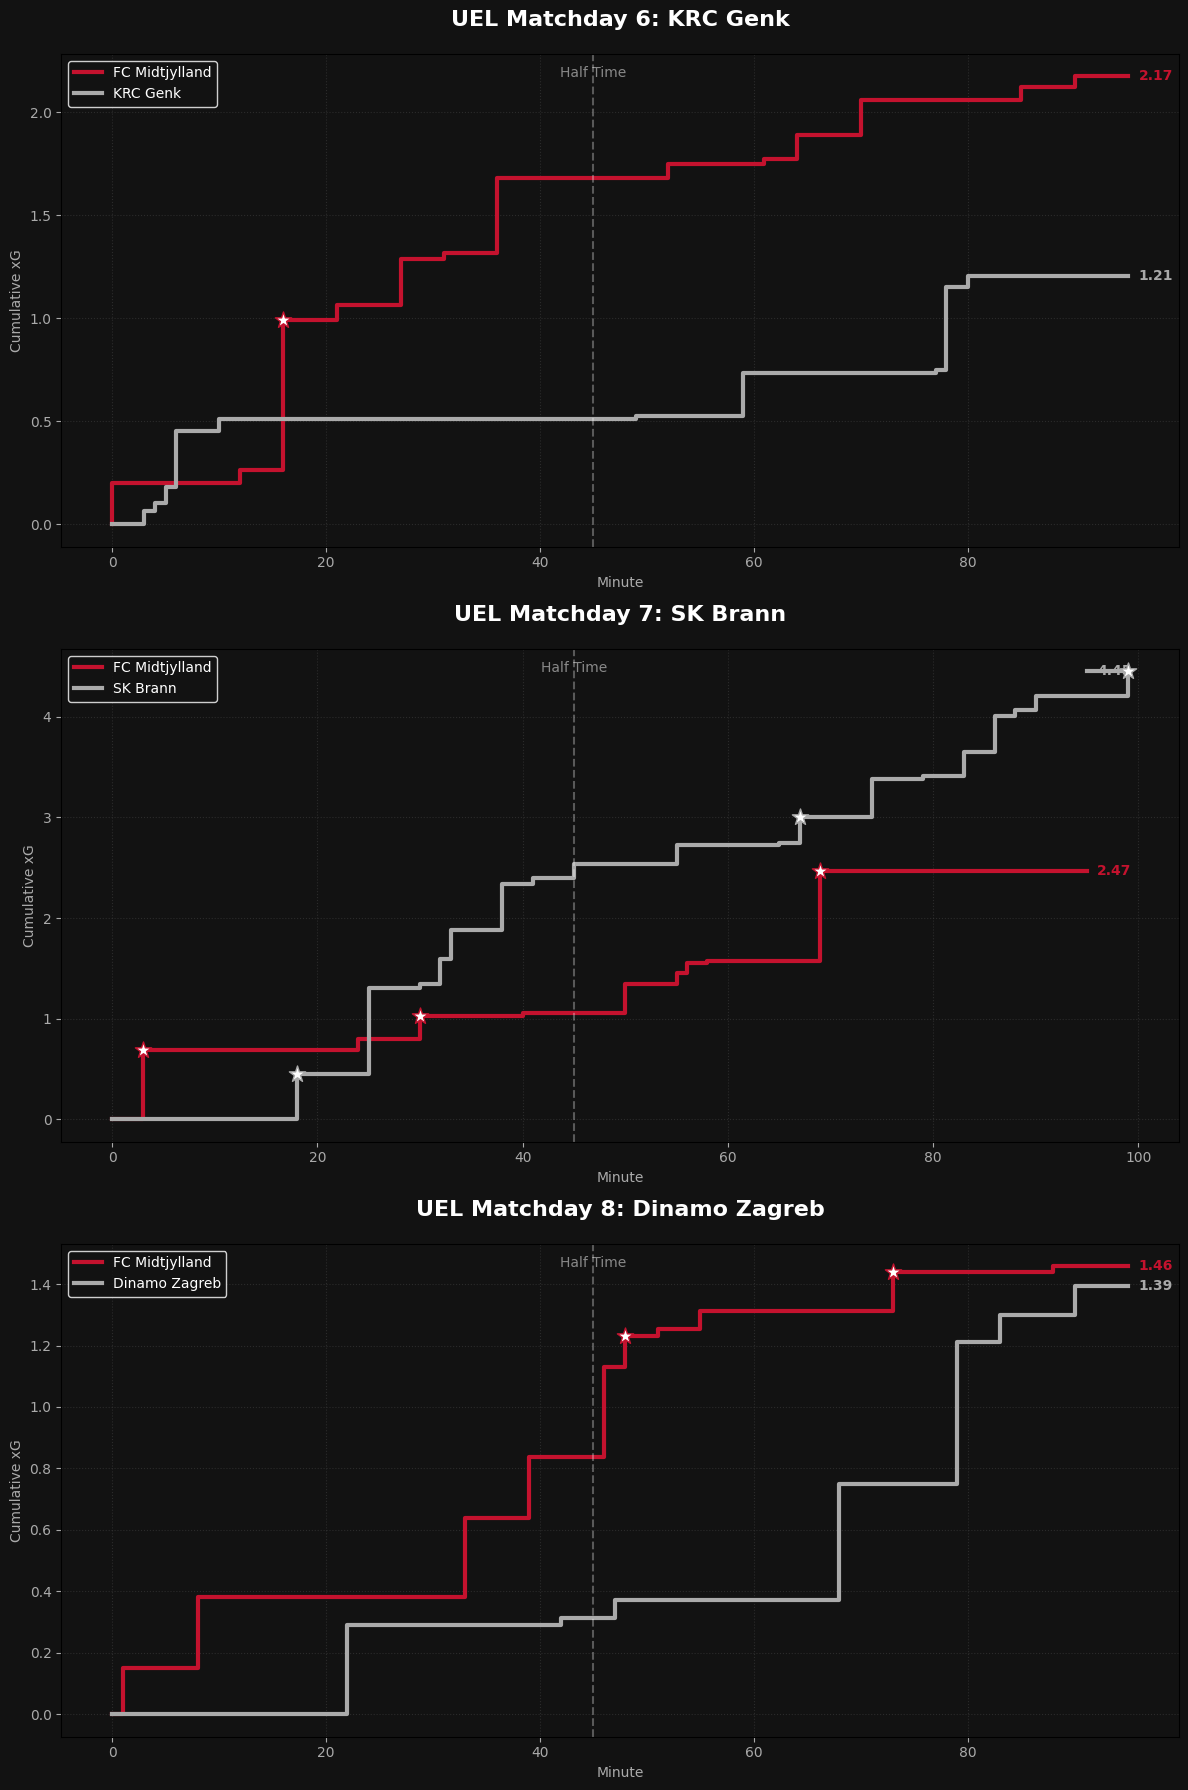

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
import ast

# Usamos la misma lógica de xG que acordamos (Fórmula Geométrica)
def calculate_estimated_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    return np.exp(-0.12 * distancia)

fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 18))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    # 1. Procesar tiros de ambos equipos
    # Filtramos eventos de tiro (13, 14, 15, 16)
    df_shots = df_match[df_match['typeId'].isin([13, 14, 15, 16])].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_estimated_xg(row.x, row.y), axis=1)

    # Separar por equipos
    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    # 2. Crear datos acumulados (Empezamos en minuto 0 con 0 xG)
    def get_cumulative_xg(shots_df):
        mins = [0] + shots_df['timeMin'].tolist() + [95] # Forzamos hasta el final
        xg_cum = [0] + np.cumsum(shots_df['xG']).tolist()
        # Repetimos el último valor para que la línea llegue al final del gráfico
        xg_cum.append(xg_cum[-1])
        return mins, xg_cum

    fcm_mins, fcm_cum = get_cumulative_xg(fcm_shots)
    opp_mins, opp_cum = get_cumulative_xg(opp_shots)

    # 3. Dibujar las líneas de "Escalón"
    ax.step(fcm_mins, fcm_cum, where='post', color='#C4122E', linewidth=3, label='FC Midtjylland')
    ax.step(opp_mins, opp_cum, where='post', color='#aaaaaa', linewidth=3, label=config['opponent'])

    # 4. Marcar los GOLES con una estrella
    fcm_goals = fcm_shots[fcm_shots['typeId'] == 16]
    opp_goals = opp_shots[opp_shots['typeId'] == 16]

    for _, goal in fcm_goals.iterrows():
        # Buscamos el valor acumulado en ese minuto para poner la estrella a la altura correcta
        y_val = fcm_shots[fcm_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        ax.scatter(goal['timeMin'], y_val, color='white', edgecolor='#C4122E', s=150, marker='*', zorder=5)

    for _, goal in opp_goals.iterrows():
        y_val = opp_shots[opp_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        ax.scatter(goal['timeMin'], y_val, color='white', edgecolor='#aaaaaa', s=150, marker='*', zorder=5)

    # 5. Estética del gráfico
    ax.axvline(45, color='white', linestyle='--', alpha=0.3) # Línea de descanso
    ax.text(45, ax.get_ylim()[1]*0.95, 'Half Time', color='white', alpha=0.5, ha='center', fontsize=10)

    ax.set_title(f"{config['label']}: {config['opponent']}", color='white', fontsize=16, pad=20, weight='bold')
    ax.set_xlabel('Minute', color='#aaaaaa')
    ax.set_ylabel('Cumulative xG', color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')
    ax.grid(color='#444444', linestyle=':', alpha=0.5)
    ax.legend(loc='upper left', facecolor='#121212', edgecolor='white', labelcolor='white')

    # Añadir texto con el xG final
    ax.text(96, fcm_cum[-1], f"{fcm_cum[-1]:.2f}", color='#C4122E', weight='bold', va='center')
    ax.text(96, opp_cum[-1], f"{opp_cum[-1]:.2f}", color='#aaaaaa', weight='bold', va='center')

plt.tight_layout()
plt.show()

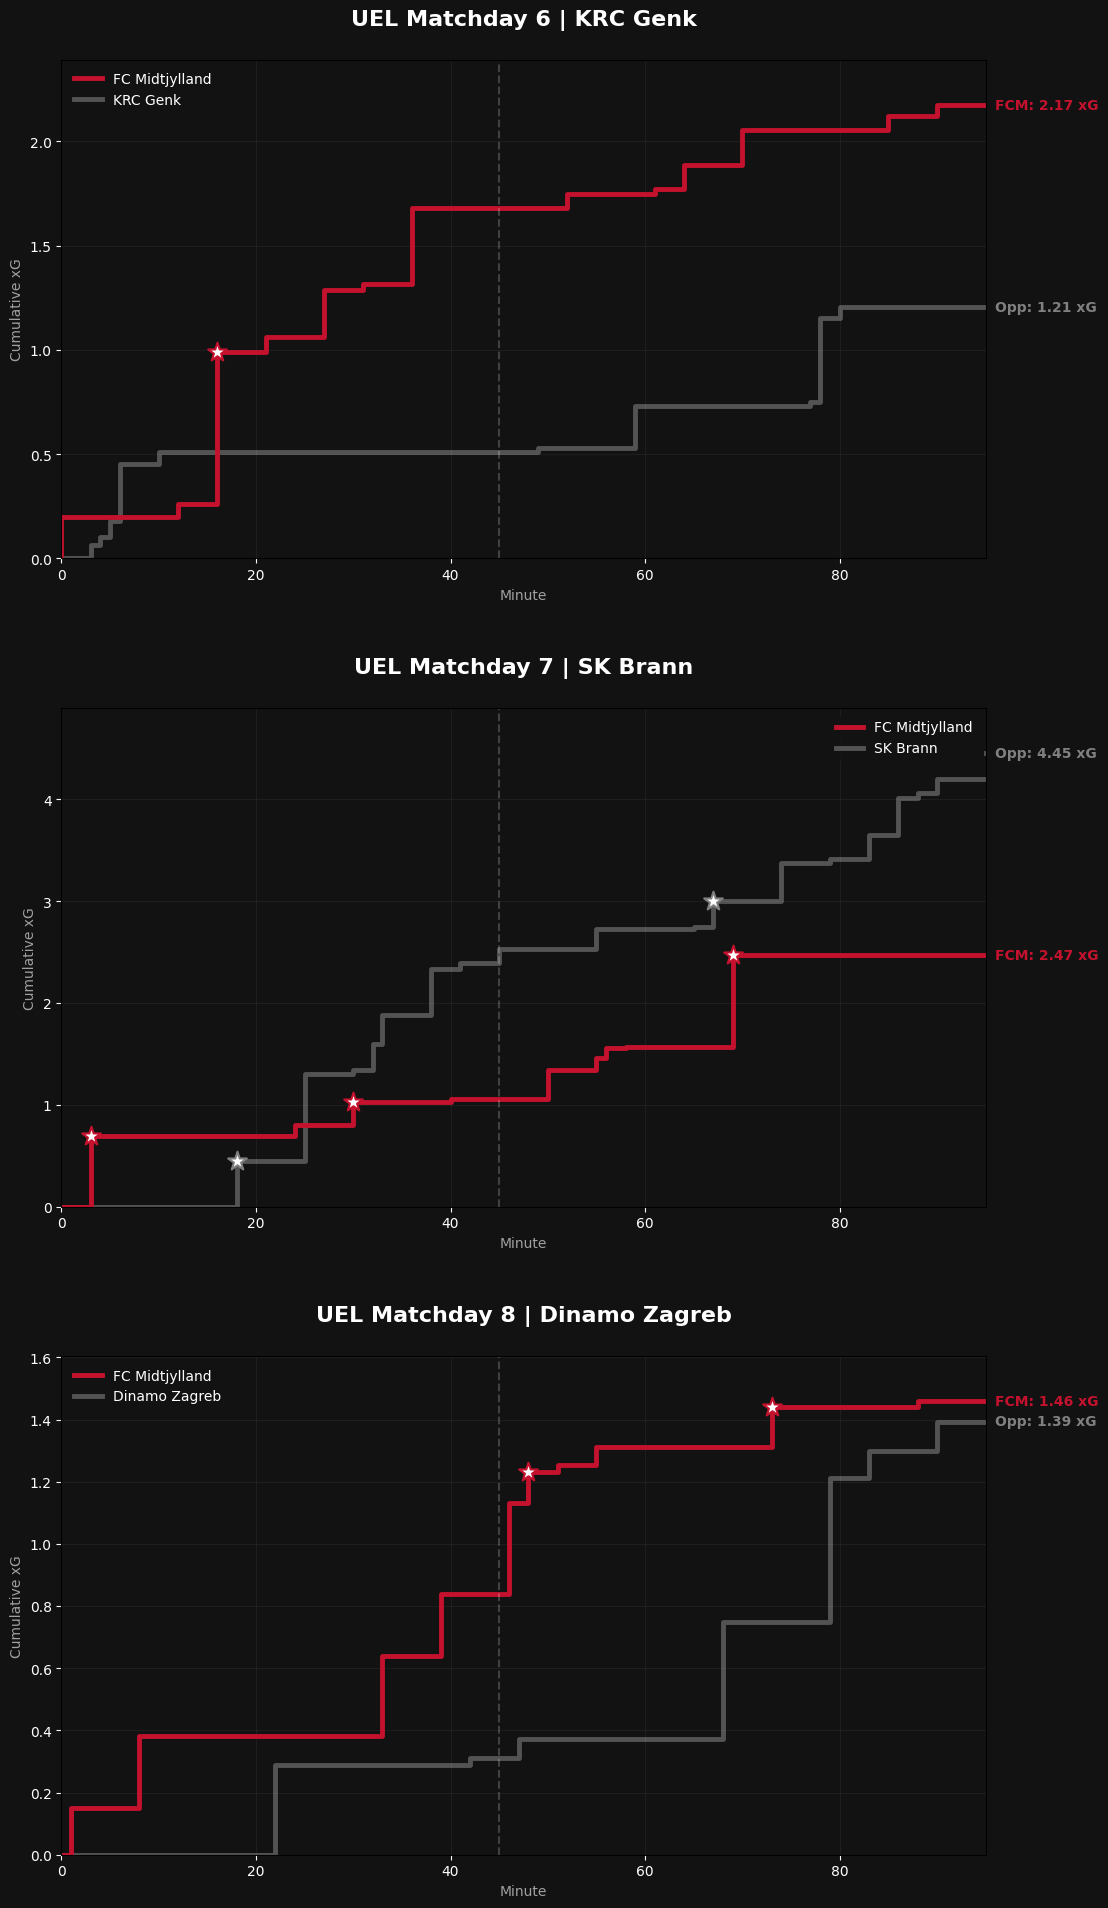

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

# 1. DEFINIMOS LA FUNCIÓN DE xG EXACTA (Igual que en el Shot Map)
def calculate_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    # Usamos 0.12 para consistencia total con el mapa anterior
    return np.exp(-0.12 * distancia)

fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 20))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    # 2. FILTRADO ESTRICTO (Mismos IDs que el Shot Map)
    shot_ids = [13, 14, 15, 16]
    df_shots = df_match[df_match['typeId'].isin(shot_ids)].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_xg(row.x, row.y), axis=1)

    # Separar equipos
    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    # 3. GENERAR ACUMULADOS SIN ERRORES DE MINUTOS
    def get_cum_data(shots_df):
        # Empezamos en 0, añadimos los minutos de los tiros, y cerramos en 95
        mins = [0] + shots_df['timeMin'].tolist() + [95] # Forzamos hasta el final
        # Empezamos en 0, acumulamos xG, y repetimos el último valor para el final
        xg_cum = [0] + np.cumsum(shots_df['xG']).tolist()
        xg_cum.append(xg_cum[-1])
        return mins, xg_cum

    fcm_x, fcm_y = get_cum_data(fcm_shots)
    opp_x, opp_y = get_cum_data(opp_shots)

    # 4. DIBUJAR LÍNEAS (post: el salto ocurre después del minuto del tiro)
    ax.step(fcm_x, fcm_y, where='post', color='#C4122E', linewidth=3.5, label='FC Midtjylland', zorder=2)
    ax.step(opp_x, opp_y, where='post', color='#808080', linewidth=3.5, label=config['opponent'], alpha=0.6, zorder=1)

    # 5. MARCAR GOLES (Solo si typeId es 16)
    for team_shots, color, label in [(fcm_shots, '#C4122E', 'FCM'), (opp_shots, '#808080', 'Opponent')]:
        goals = team_shots[team_shots['typeId'] == 16]
        for _, goal in goals.iterrows():
            # Buscamos el xG acumulado hasta ese momento para situar la estrella
            cum_at_goal = team_shots[team_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
            ax.scatter(goal['timeMin'], cum_at_goal, color='white', edgecolor=color,
                       s=200, marker='*', zorder=5, lw=1.5)

    # ESTÉTICA FINAL
    ax.set_title(f"{config['label']} | {config['opponent']}", color='white', size=16, weight='bold', pad=25)
    ax.set_xlim(0, 95)
    ax.set_ylim(0, max(max(fcm_y), max(opp_y)) * 1.1) # Ajuste dinámico de altura

    # Etiquetas con los totales finales para verificar coherencia
    ax.text(96, fcm_y[-1], f"FCM: {fcm_y[-1]:.2f} xG", color='#C4122E', weight='bold', va='center')
    ax.text(96, opp_y[-1], f"Opp: {opp_y[-1]:.2f} xG", color='#808080', weight='bold', va='center')

    # Línea de descanso
    ax.axvline(45, color='white', linestyle='--', alpha=0.2)
    ax.set_xlabel('Minute', color='white', alpha=0.6)
    ax.set_ylabel('Cumulative xG', color='white', alpha=0.6)
    ax.tick_params(colors='white') # Removed alpha argument
    ax.grid(True, color='white', alpha=0.05)
    ax.legend(facecolor='#121212', edgecolor='none', labelcolor='white')

plt.tight_layout(pad=4)
plt.show()

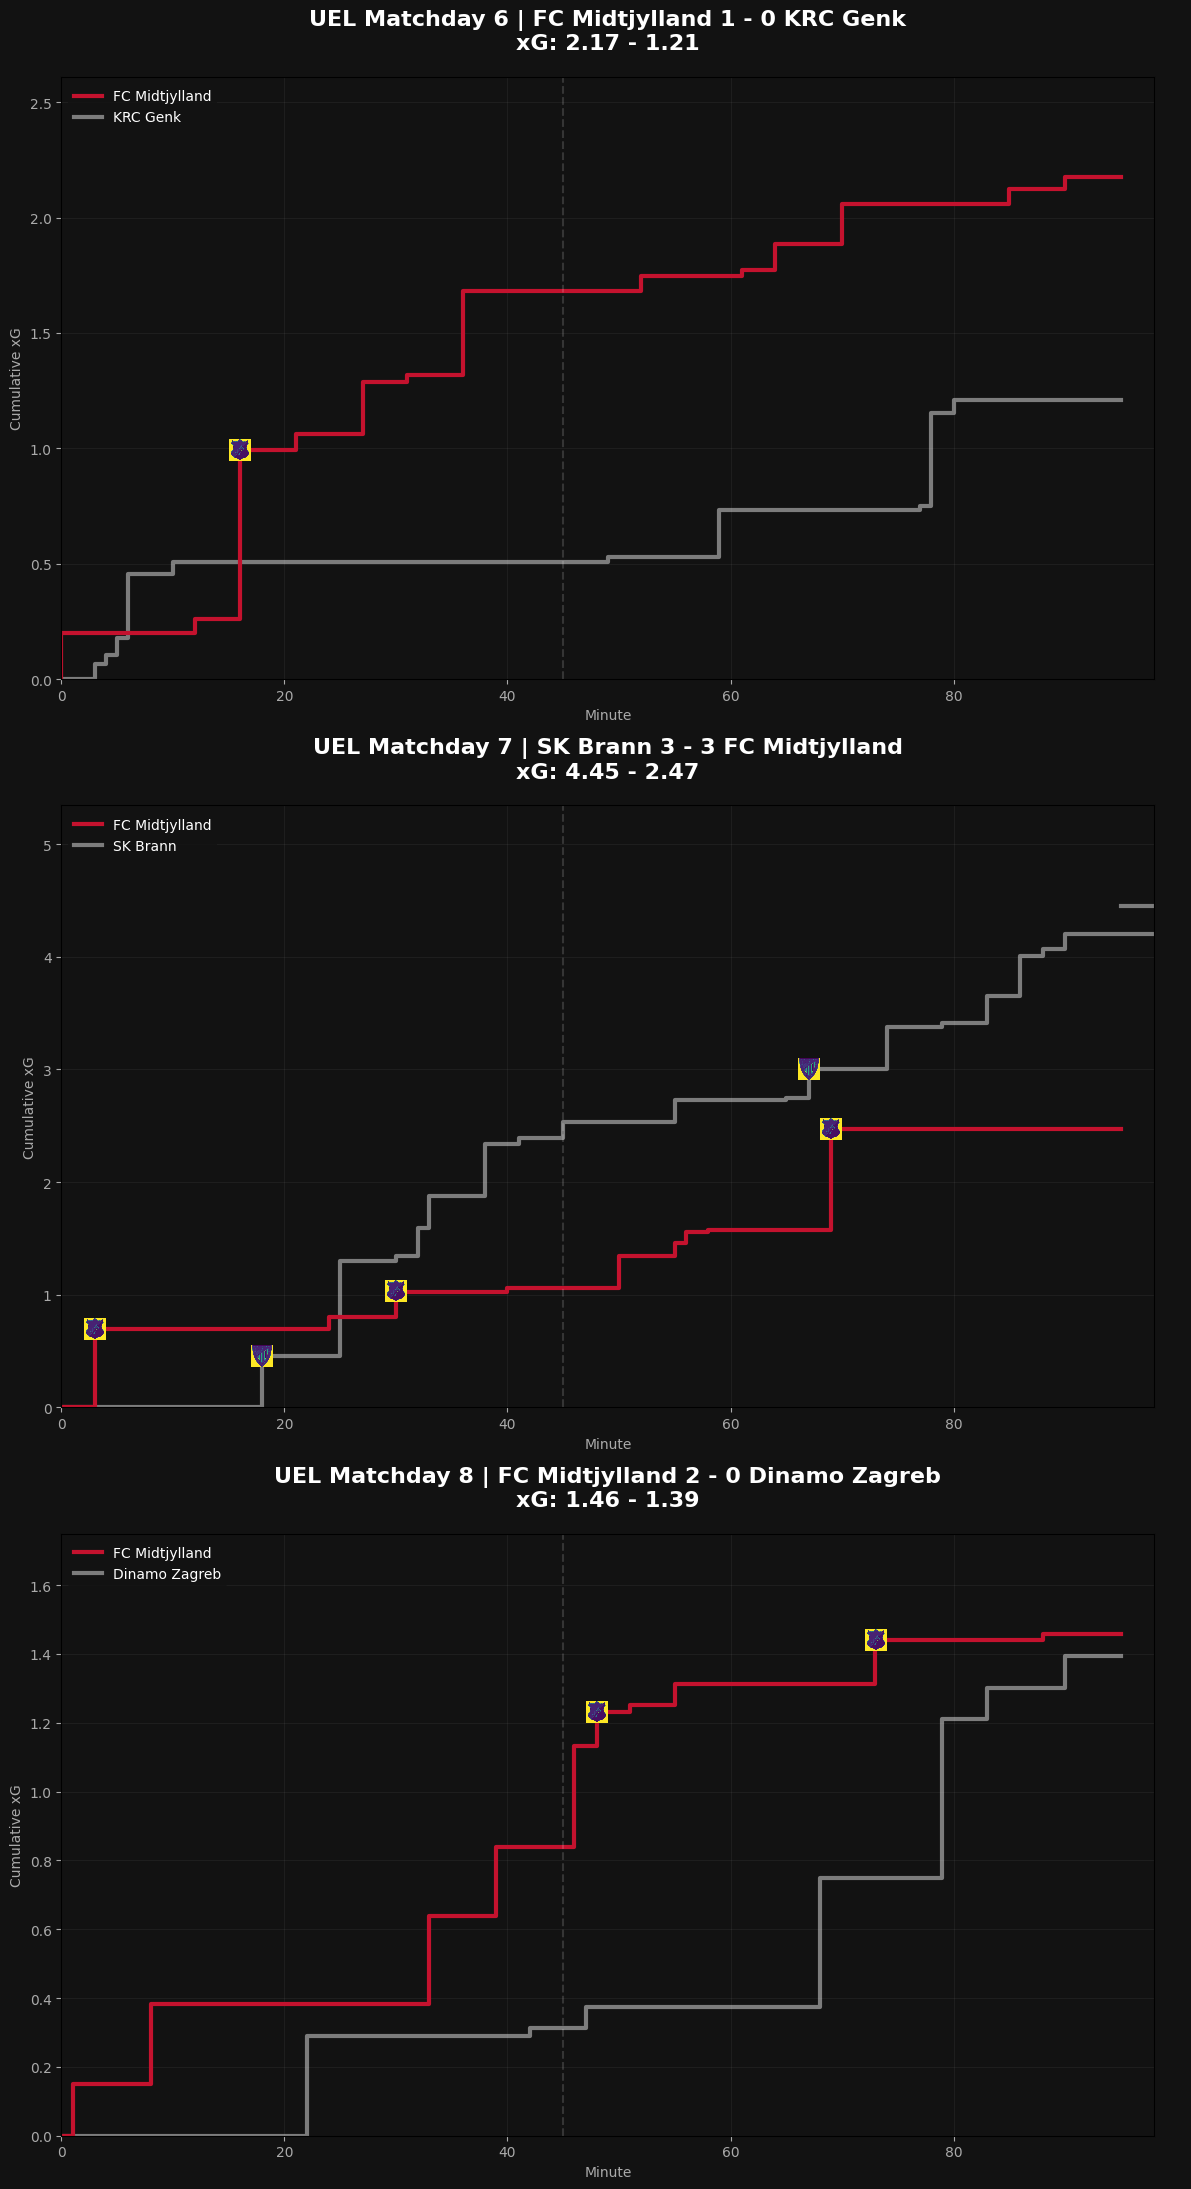

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from urllib.request import urlopen
import numpy as np
import pandas as pd
import os

# --- 1. CONFIGURACIÓN DE ESCUDOS ---
# Enlaces a imágenes PNG transparentes (si alguno falla en el futuro, solo cámbialo)
logos = {
    "FC Midtjylland": "https://images.fotmob.com/image_resources/logo/teamlogo/8226.png",
    "KRC Genk": "https://images.fotmob.com/image_resources/logo/teamlogo/9905.png",
    "SK Brann": "https://images.fotmob.com/image_resources/logo/teamlogo/8315.png",
    "Dinamo Zagreb": "https://images.fotmob.com/image_resources/logo/teamlogo/6011.png"
}

# Función auxiliar para pintar la imagen en el gráfico
def plot_logo(ax, image_url, x, y, zoom=0.15):
    try:
        img = Image.open(urlopen(image_url))
        imagebox = OffsetImage(img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
    except:
        # Si falla la imagen, pintamos una estrella como respaldo
        ax.scatter(x, y, marker='*', s=200, color='white', edgecolors='red')

# --- 2. CÁLCULO DE xG (Fórmula Geométrica Consistente) ---
def calculate_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    return np.exp(-0.12 * distancia)

# --- 3. GENERACIÓN DEL GRÁFICO ---
fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 22))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    # Cargar datos
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    # Filtrar tiros y calcular xG
    df_shots = df_match[df_match['typeId'].isin([13, 14, 15, 16])].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_xg(row.x, row.y), axis=1)

    # Calcular Marcador Real
    goals_fcm = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    # Separar datos por equipos
    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    # Crear líneas acumuladas
    def get_cum_data(shots_df):
        x = [0] + shots_df['timeMin'].tolist() + [95]
        y = [0] + np.cumsum(shots_df['xG']).tolist()
        y = y + [y[-1]] # Repetir último valor
        # Removed: x = x + [x[-1]]
        return x, y

    fcm_x, fcm_y = get_cum_data(fcm_shots)
    opp_x, opp_y = get_cum_data(opp_shots)

    # Dibujar líneas (Step Chart)
    ax.step(fcm_x, fcm_y, where='post', color='#C4122E', linewidth=3, label='FC Midtjylland', zorder=2)
    ax.step(opp_x, opp_y, where='post', color='#aaaaaa', linewidth=3, label=config['opponent'], alpha=0.7, zorder=1)

    # --- AÑADIR ESCUDOS EN LOS GOLES ---
    # Goles FCM
    for _, goal in fcm_shots[fcm_shots['typeId'] == 16].iterrows():
        cum_val = fcm_shots[fcm_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        plot_logo(ax, logos["FC Midtjylland"], goal['timeMin'], cum_val, zoom=0.08) # Ajusta zoom si es necesario

    # Goles Rival
    for _, goal in opp_shots[opp_shots['typeId'] == 16].iterrows():
        cum_val = opp_shots[opp_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        # Buscamos el logo del rival usando el nombre en config
        opp_logo_url = logos.get(config['opponent'], logos.get("Dinamo Zagreb")) # Fallback seguro
        plot_logo(ax, opp_logo_url, goal['timeMin'], cum_val, zoom=0.08)

    # --- TÍTULOS E INFORMACIÓN ---
    total_xg_fcm = fcm_y[-1]
    total_xg_opp = opp_y[-1]

    # Determinar orden local/visitante para el texto
    if "vs FC Midtjylland" in config["file"]: # FCM Visitante
        title_res = f"{config['opponent']} {goals_opp} - {goals_fcm} FC Midtjylland"
        xg_res = f"xG: {total_xg_opp:.2f} - {total_xg_fcm:.2f}"
    else: # FCM Local
        title_res = f"FC Midtjylland {goals_fcm} - {goals_opp} {config['opponent']}"
        xg_res = f"xG: {total_xg_fcm:.2f} - {total_xg_opp:.2f}"

    ax.set_title(f"{config['label']} | {title_res}\n{xg_res}", color='white', size=16, weight='bold', pad=20)

    # Detalles estéticos finales
    ax.set_xlim(0, 98)
    ax.set_ylim(0, max(total_xg_fcm, total_xg_opp) * 1.2)
    ax.axvline(45, color='white', linestyle='--', alpha=0.15)
    ax.grid(color='white', alpha=0.05)

    # Etiquetas ejes
    ax.set_xlabel('Minute', color='#aaaaaa')
    ax.set_ylabel('Cumulative xG', color='#aaaaaa')
    ax.tick_params(colors='#aaaaaa')

    # Leyenda simple (sin logos para no saturar)
    ax.legend(loc='upper left', facecolor='#121212', edgecolor='none', labelcolor='white')

plt.tight_layout()
plt.show()

⚠️ No se pudo cargar la imagen del balón. Usaremos un punto blanco.


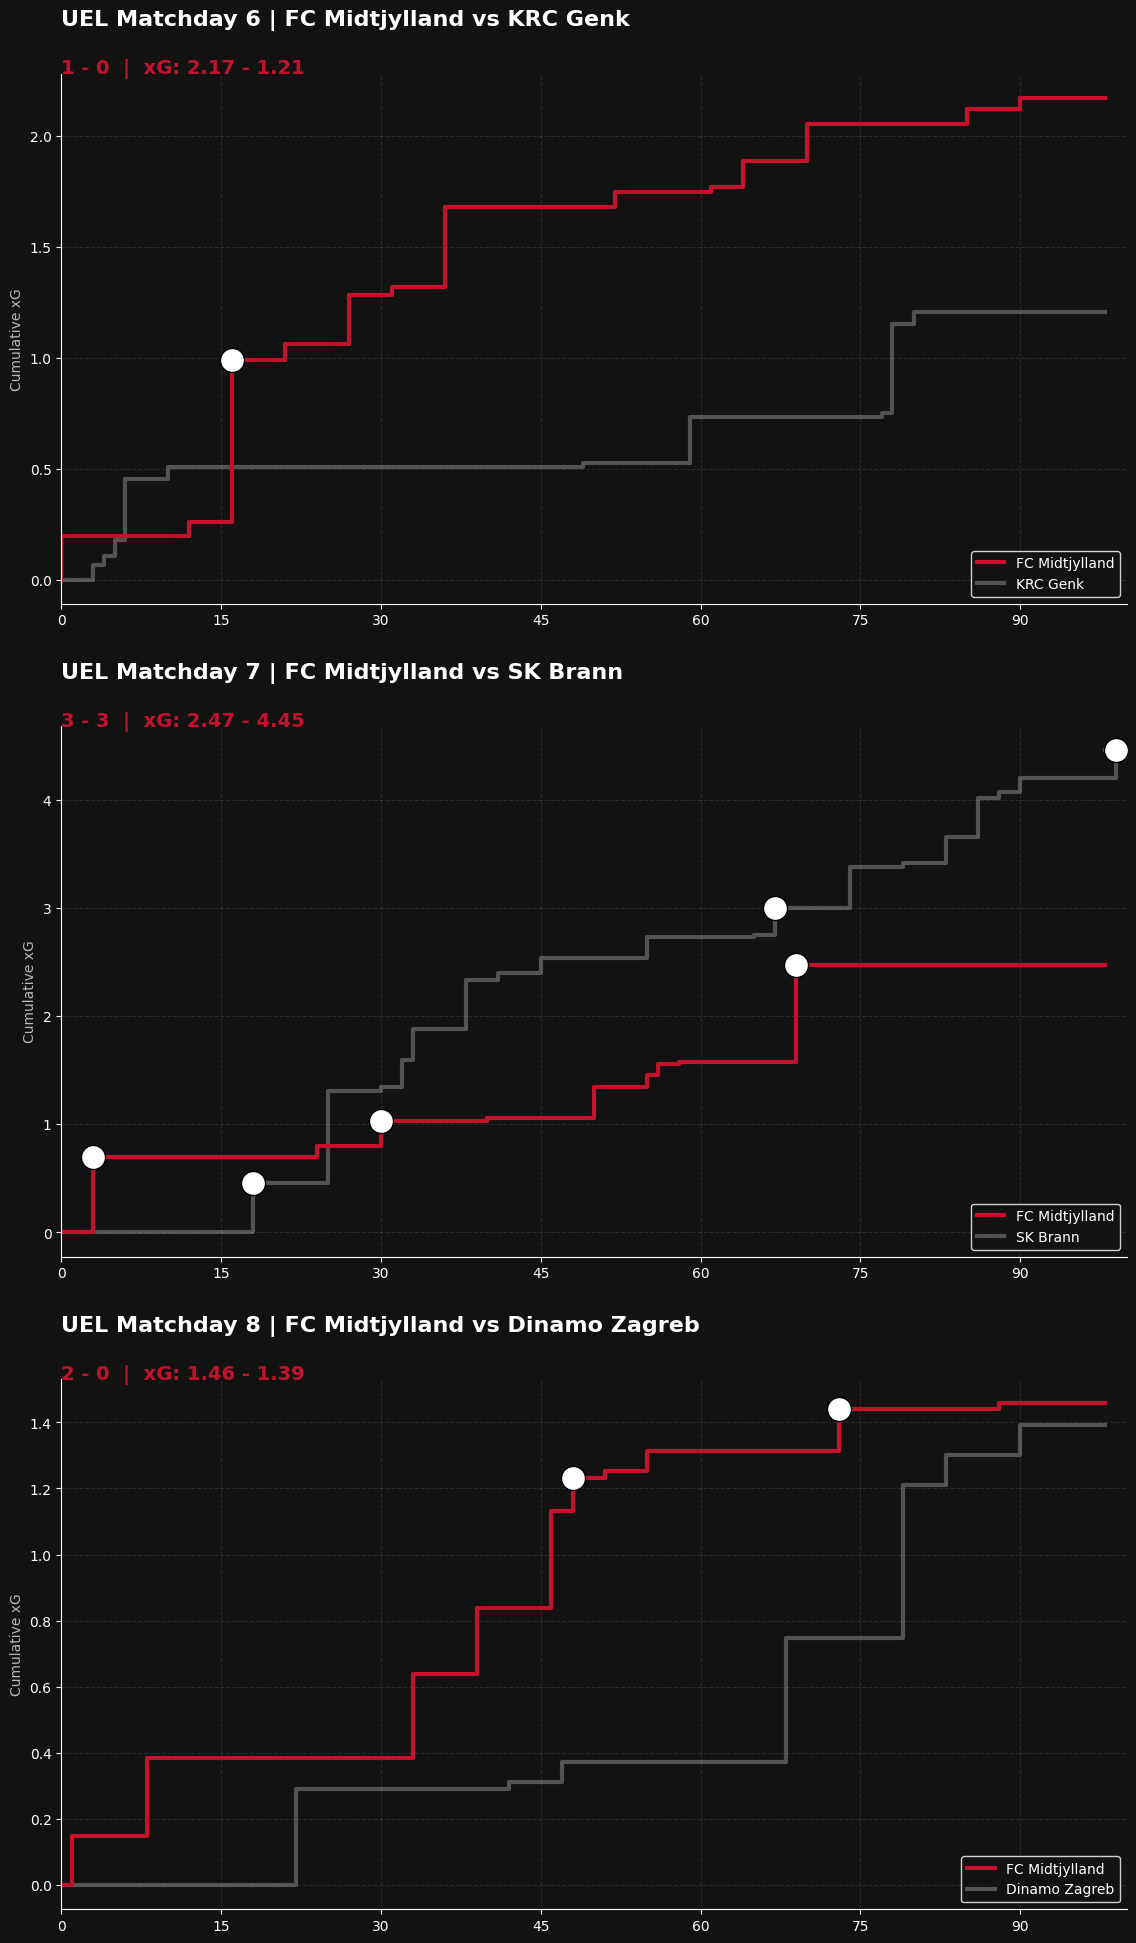

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from urllib.request import urlopen
import numpy as np
import pandas as pd
import os

# --- 1. CONFIGURACIÓN DEL BALÓN ---
# Usamos un icono de balón limpio y fiable
ball_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Soccerball.svg/120px-Soccerball.svg.png"
try:
    ball_img = Image.open(urlopen(ball_url))
except:
    print("⚠️ No se pudo cargar la imagen del balón. Usaremos un punto blanco.")
    ball_img = None

def plot_ball(ax, x, y, zoom=0.25):
    if ball_img:
        imagebox = OffsetImage(ball_img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False)
        ax.add_artist(ab)
    else:
        # Fallback si no hay internet: Punto blanco con borde negro
        ax.scatter(x, y, s=300, c='white', edgecolors='black', zorder=10)

# --- 2. CÁLCULO DE xG (Consistente) ---
def calculate_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    return np.exp(-0.12 * distancia)

# --- 3. GENERACIÓN DEL GRÁFICO ---
fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 20))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    # Cargar y filtrar
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    # Procesar tiros y xG
    df_shots = df_match[df_match['typeId'].isin([13, 14, 15, 16])].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_xg(row.x, row.y), axis=1)

    # Calcular Marcador Real (FCM vs Rival)
    goals_fcm_count = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp_count = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    # Separar datos
    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    # Función acumulativa
    def get_cum_data(shots_df):
        x = [0] + shots_df['timeMin'].tolist() + [98] # Extendemos un poco más del 90
        y = [0] + np.cumsum(shots_df['xG']).tolist()
        y = y + [y[-1]] # Repetir último valor
        # Removed the problematic line: x = x + [x[-1]]
        return x, y # Now return the full lists, as they should have matching lengths

    fcm_x, fcm_y = get_cum_data(fcm_shots)
    opp_x, opp_y = get_cum_data(opp_shots)

    # DIBUJAR LÍNEAS
    ax.step(fcm_x, fcm_y, where='post', color='#C4122E', linewidth=3, label='FC Midtjylland', zorder=2)
    ax.step(opp_x, opp_y, where='post', color='#808080', linewidth=3, label=config['opponent'], alpha=0.6, zorder=1)

    # PONER BALONES EN LOS GOLES
    # Goles FCM
    for _, goal in fcm_shots[fcm_shots['typeId'] == 16].iterrows():
        cum_val = fcm_shots[fcm_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        plot_ball(ax, goal['timeMin'], cum_val, zoom=0.18) # Balón FCM

    # Goles Rival
    for _, goal in opp_shots[opp_shots['typeId'] == 16].iterrows():
        cum_val = opp_shots[opp_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        plot_ball(ax, goal['timeMin'], cum_val, zoom=0.18) # Balón Rival

    # --- FORMATO DE EJES Y TÍTULOS ---
    total_xg_fcm = fcm_y[-1]
    total_xg_opp = opp_y[-1]

    # Título Línea 1
    title_l1 = f"{config['label']} | FC Midtjylland vs {config['opponent']}"
    # Título Línea 2 (Siempre FCM primero para coherencia con el título)
    title_l2 = f"{goals_fcm_count} - {goals_opp_count}  |  xG: {total_xg_fcm:.2f} - {total_xg_opp:.2f}"

    ax.text(0, max(fcm_y[-1], opp_y[-1])*1.15, title_l1, color='white', fontsize=16, weight='bold', ha='left')
    ax.text(0, max(fcm_y[-1], opp_y[-1])*1.05, title_l2, color='#C4122E', fontsize=14, weight='bold', ha='left')

    # Configuración Eje X (Minutos)
    ax.set_xticks(np.arange(0, 106, 15)) # 0, 15, 30, 45, 60, 75, 90, 105
    ax.set_xlim(0, 100)

    # Configuración general
    ax.grid(color='white', alpha=0.1, linestyle='--')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', colors='white', labelsize=10)
    ax.tick_params(axis='y', colors='white', labelsize=10)
    ax.set_ylabel('Cumulative xG', color='white', alpha=0.7)

    # Leyenda abajo a la derecha
    ax.legend(loc='lower right', facecolor='#121212', edgecolor='white', labelcolor='white')

plt.tight_layout(pad=3)
plt.show()

⚠️ No se pudo cargar la imagen del balón. Usaremos un punto blanco.


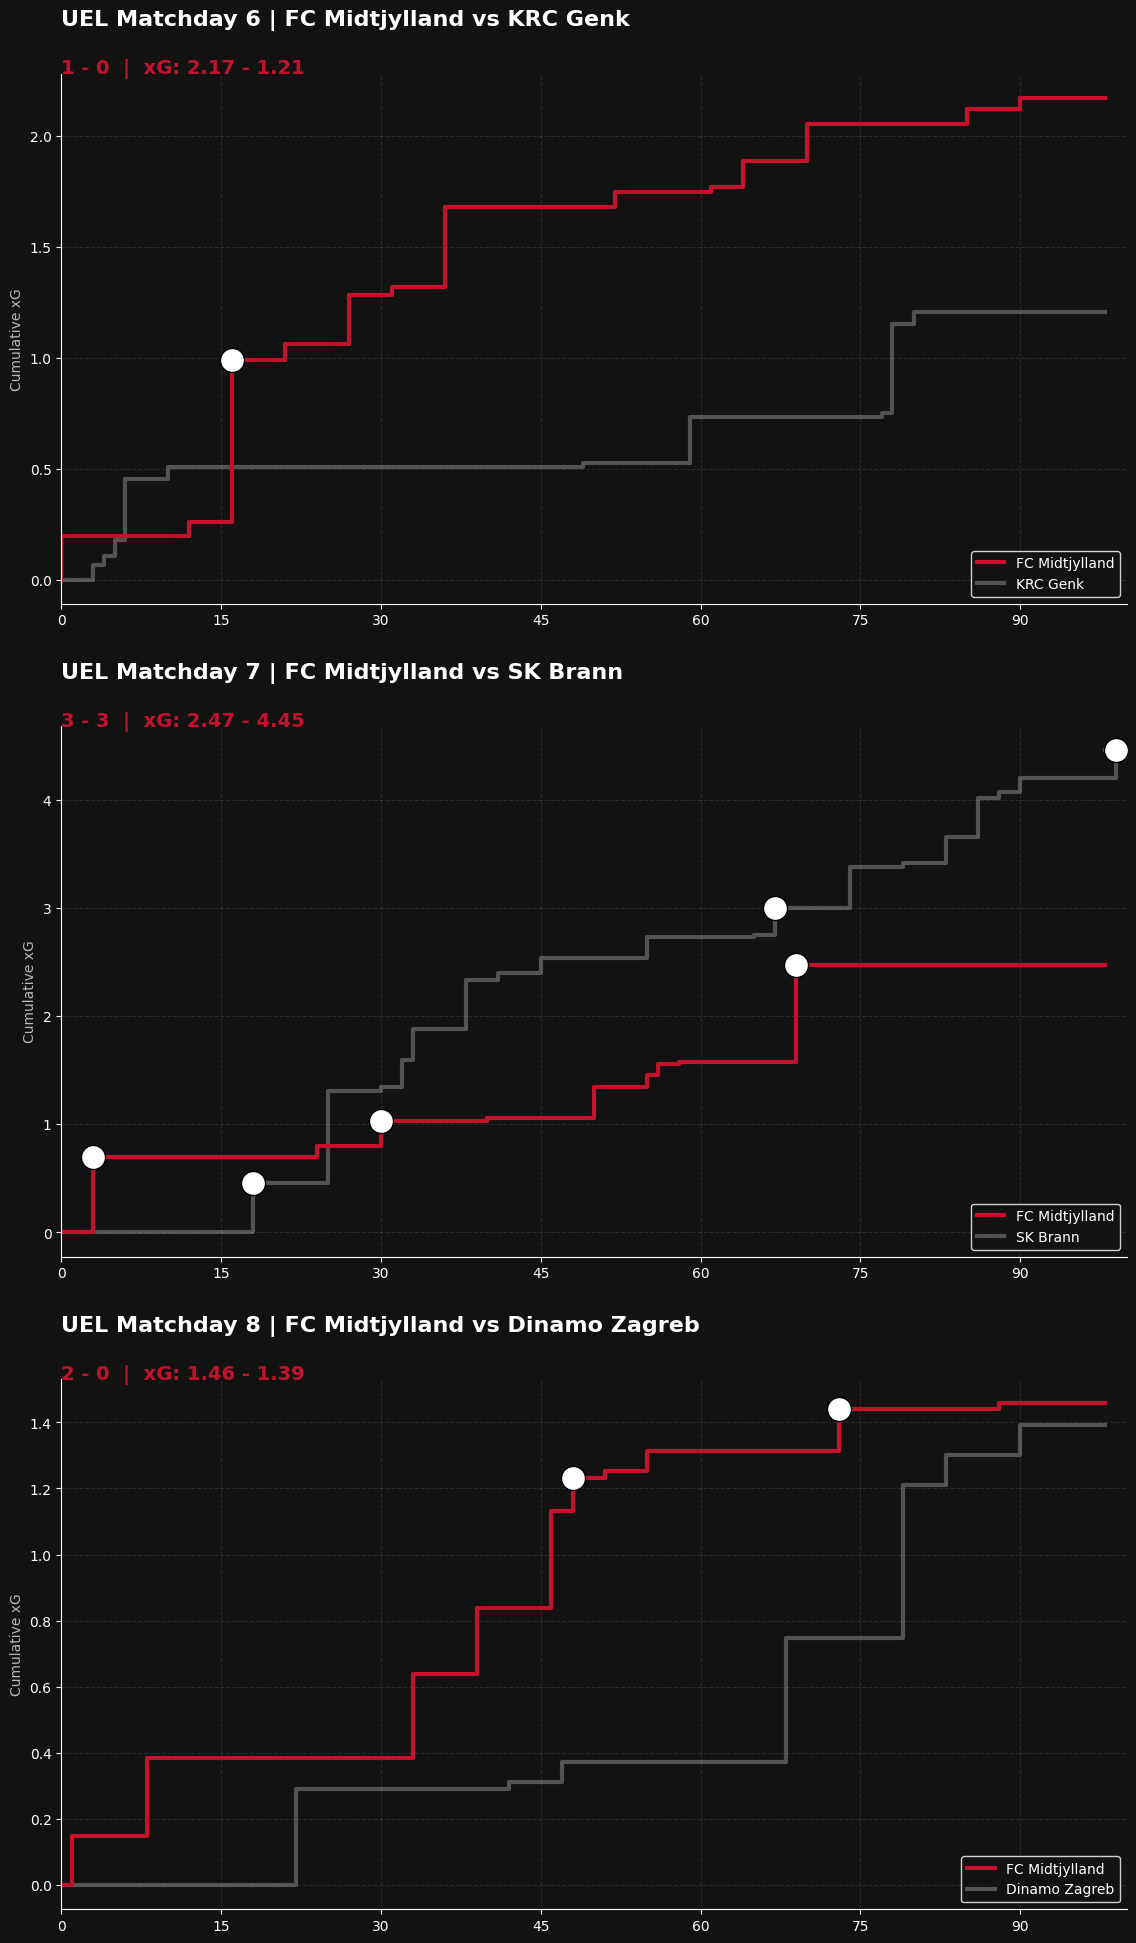

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from urllib.request import urlopen
import numpy as np
import pandas as pd
import os

# --- 1. CONFIGURACIÓN DEL BALÓN ---
ball_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Soccerball.svg/120px-Soccerball.svg.png"
try:
    ball_img = Image.open(urlopen(ball_url))
except:
    print("⚠️ No se pudo cargar la imagen del balón. Usaremos un punto blanco.")
    ball_img = None

def plot_ball(ax, x, y, zoom=0.25):
    if ball_img:
        imagebox = OffsetImage(ball_img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, zorder=10) # zorder para que esté encima
        ax.add_artist(ab)
    else:
        ax.scatter(x, y, s=300, c='white', edgecolors='black', zorder=10)

# --- 2. CÁLCULO DE xG (Consistente) ---
def calculate_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    return np.exp(-0.12 * distancia)

# --- 3. GENERACIÓN DEL GRÁFICO ---
fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 20))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    df_shots = df_match[df_match['typeId'].isin([13, 14, 15, 16])].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_xg(row.x, row.y), axis=1)

    goals_fcm_count = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp_count = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    def get_cum_data(shots_df):
        x = [0] + shots_df['timeMin'].tolist() + [98]
        y = [0] + np.cumsum(shots_df['xG']).tolist()
        y = y + [y[-1]]
        # Remove the problematic line: x = x + [x[-1]]
        return x, y

    fcm_x, fcm_y = get_cum_data(fcm_shots)
    opp_x, opp_y = get_cum_data(opp_shots)

    # DIBUJAR LÍNEAS
    ax.step(fcm_x, fcm_y, where='post', color='#C4122E', linewidth=3, label='FC Midtjylland', zorder=2)
    ax.step(opp_x, opp_y, where='post', color='#808080', linewidth=3, label=config['opponent'], alpha=0.6, zorder=1)

    # PONER BALONES EN LOS GOLES
    for _, goal in fcm_shots[fcm_shots['typeId'] == 16].iterrows():
        cum_val = fcm_shots[fcm_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        plot_ball(ax, goal['timeMin'], cum_val, zoom=0.18) # Balón FCM

    # Goles Rival
    for _, goal in opp_shots[opp_shots['typeId'] == 16].iterrows():
        cum_val = opp_shots[opp_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        plot_ball(ax, goal['timeMin'], cum_val, zoom=0.18) # Balón Rival

    # --- FORMATO DE EJES Y TÍTULOS ---
    total_xg_fcm = fcm_y[-1]
    total_xg_opp = opp_y[-1]

    # Título Línea 1
    title_l1 = f"{config['label']} | FC Midtjylland vs {config['opponent']}"
    # Título Línea 2 (Siempre FCM primero para coherencia con el título)
    title_l2 = f"{goals_fcm_count} - {goals_opp_count}  |  xG: {total_xg_fcm:.2f} - {total_xg_opp:.2f}"

    ax.text(0, max(fcm_y[-1], opp_y[-1])*1.15, title_l1, color='white', fontsize=16, weight='bold', ha='left')
    ax.text(0, max(fcm_y[-1], opp_y[-1])*1.05, title_l2, color='#C4122E', fontsize=14, weight='bold', ha='left')

    # Configuración Eje X (Minutos)
    ax.set_xticks(np.arange(0, 106, 15)) # 0, 15, 30, 45, 60, 75, 90, 105
    ax.set_xlim(0, 100)

    # Configuración general
    ax.grid(color='white', alpha=0.1, linestyle='--')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='x', colors='white', labelsize=10)
    ax.tick_params(axis='y', colors='white', labelsize=10)
    ax.set_ylabel('Cumulative xG', color='white', alpha=0.7)

    # Leyenda abajo a la derecha
    ax.legend(loc='lower right', facecolor='#121212', edgecolor='white', labelcolor='white')

plt.tight_layout(pad=3)
plt.show()

In [ ]:
# --- TÍTULOS E INFORMACIÓN (CENTRADOS CON TRANSAXES) ---
total_xg_fcm = fcm_y[-1]
total_xg_opp = opp_y[-1]

# Título Línea 1: Matchday y Equipos
title_l1 = f"{config['label']} | FC Midtjylland vs {config['opponent']}"
# Usamos x=0.5 y transform=ax.transAxes para centro absoluto
ax.text(0.5, 1.12, title_l1, color='white', fontsize=16, weight='bold',
        ha='center', va='center', transform=ax.transAxes)

# Título Línea 2: Resultado y xG
title_l2 = f"{goals_fcm_count} - {goals_opp_count}  |  xG: {total_xg_fcm:.2f} - {total_xg_opp:.2f}"
ax.text(0.5, 1.05, title_l2, color='#C4122E', fontsize=14, weight='bold',
        ha='center', va='center', transform=ax.transAxes)

# --- LÍNEA DE HALF TIME (CENTRO TEMPORAL) ---
ax.axvline(45, color='white', linestyle='--', alpha=0.3, zorder=0)
# También centramos el texto de Half Time sobre la línea
ax.text(45, ax.get_ylim()[1] * 0.97, 'Half Time', color='white',
        alpha=0.5, ha='center', fontsize=10, va='top')

Text(45, 1.4850714779701748, 'Half Time')

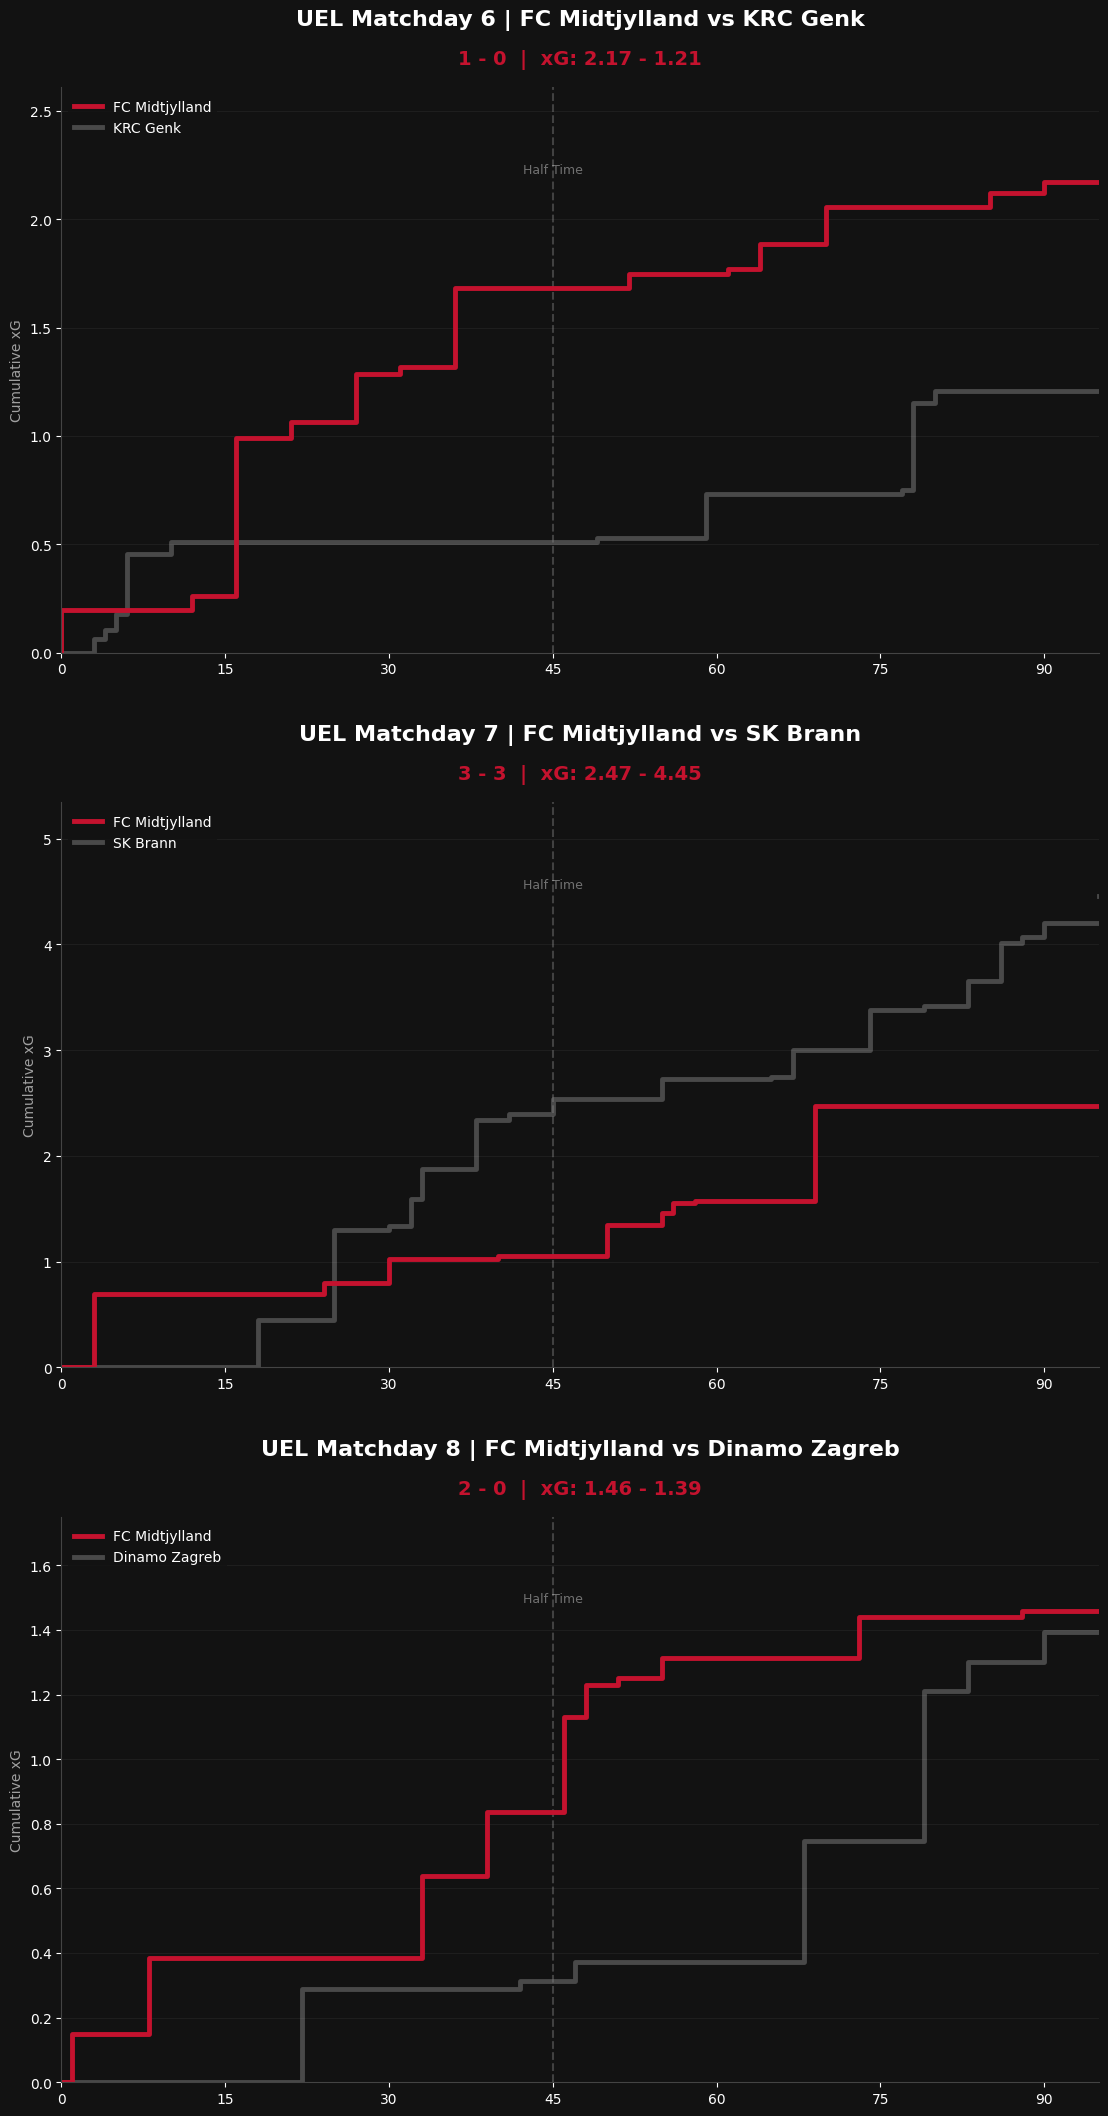

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from urllib.request import urlopen
import numpy as np
import pandas as pd
import os

# --- 1. CONFIGURACIÓN DEL BALÓN ---
ball_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Soccerball.svg/120px-Soccerball.svg.png"
try:
    ball_img = Image.open(urlopen(ball_url))
except:
    ball_img = None

def plot_ball(ax, x, y, zoom=0.18):
    if ball_img:
        imagebox = OffsetImage(ball_img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, zorder=10)
        ax.add_artist(ab)

# --- 2. CÁLCULO DE xG ---
def calculate_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    return np.exp(-0.12 * distancia)

# --- 3. GENERACIÓN DEL GRÁFICO ---
fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 22))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    # Procesar tiros
    df_shots = df_match[df_match['typeId'].isin([13, 14, 15, 16])].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_xg(row.x, row.y), axis=1)

    # Marcador
    goals_fcm = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    # Separar datos
    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    def get_cum_data(shots_df):
        x = [0] + shots_df['timeMin'].tolist() + [95]
        y = [0] + np.cumsum(shots_df['xG']).tolist()
        y = y + [y[-1]]
        # Remove the problematic line: x = x + [x[-1]]
        return x, y

    fcm_x, fcm_y = get_cum_data(fcm_shots)
    opp_x, opp_y = get_cum_data(opp_shots)

    # Dibujar líneas
    ax.step(fcm_x, fcm_y, where='post', color='#C4122E', linewidth=3.5, label='FC Midtjylland', zorder=2)
    ax.step(opp_x, opp_y, where='post', color='#808080', linewidth=3.5, label=config['opponent'], alpha=0.5, zorder=1)

    # Balones en los goles
    for team_shots in [fcm_shots, opp_shots]:
        for _, goal in team_shots[team_shots['typeId'] == 16].iterrows():
            cum_val = team_shots[team_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
            plot_ball(ax, goal['timeMin'], cum_val)

    # --- TÍTULOS CENTRADOS (TRANS AXES) ---
    title_l1 = f"{config['label']} | FC Midtjylland vs {config['opponent']}"
    title_l2 = f"{goals_fcm} - {goals_opp}  |  xG: {fcm_y[-1]:.2f} - {opp_y[-1]:.2f}"

    # El 0.5 indica el centro exacto del ancho del gráfico
    ax.text(0.5, 1.12, title_l1, transform=ax.transAxes, color='white',
            fontsize=16, weight='bold', ha='center', va='center')
    ax.text(0.5, 1.05, title_l2, transform=ax.transAxes, color='#C4122E',
            fontsize=14, weight='bold', ha='center', va='center')

    # --- LÍNEA DE DESCANSO ---
    ax.axvline(45, color='white', linestyle='--', alpha=0.2, zorder=0)
    ax.text(45, ax.get_ylim()[1]*0.97, 'Half Time', color='white', alpha=0.4, ha='center', fontsize=9)

    # Configuración de Ejes
    ax.set_xticks([0, 15, 30, 45, 60, 75, 90])
    ax.set_xlim(0, 95)
    ax.set_ylim(0, max(fcm_y[-1], opp_y[-1]) * 1.2)
    ax.grid(axis='y', color='white', alpha=0.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_color('#444444')
    ax.spines['left'].set_color('#444444')
    ax.tick_params(colors='white', labelsize=10)
    ax.set_ylabel('Cumulative xG', color='white', alpha=0.6)
    ax.legend(loc='upper left', facecolor='#121212', edgecolor='none', labelcolor='white')

plt.tight_layout(pad=4)
plt.show()

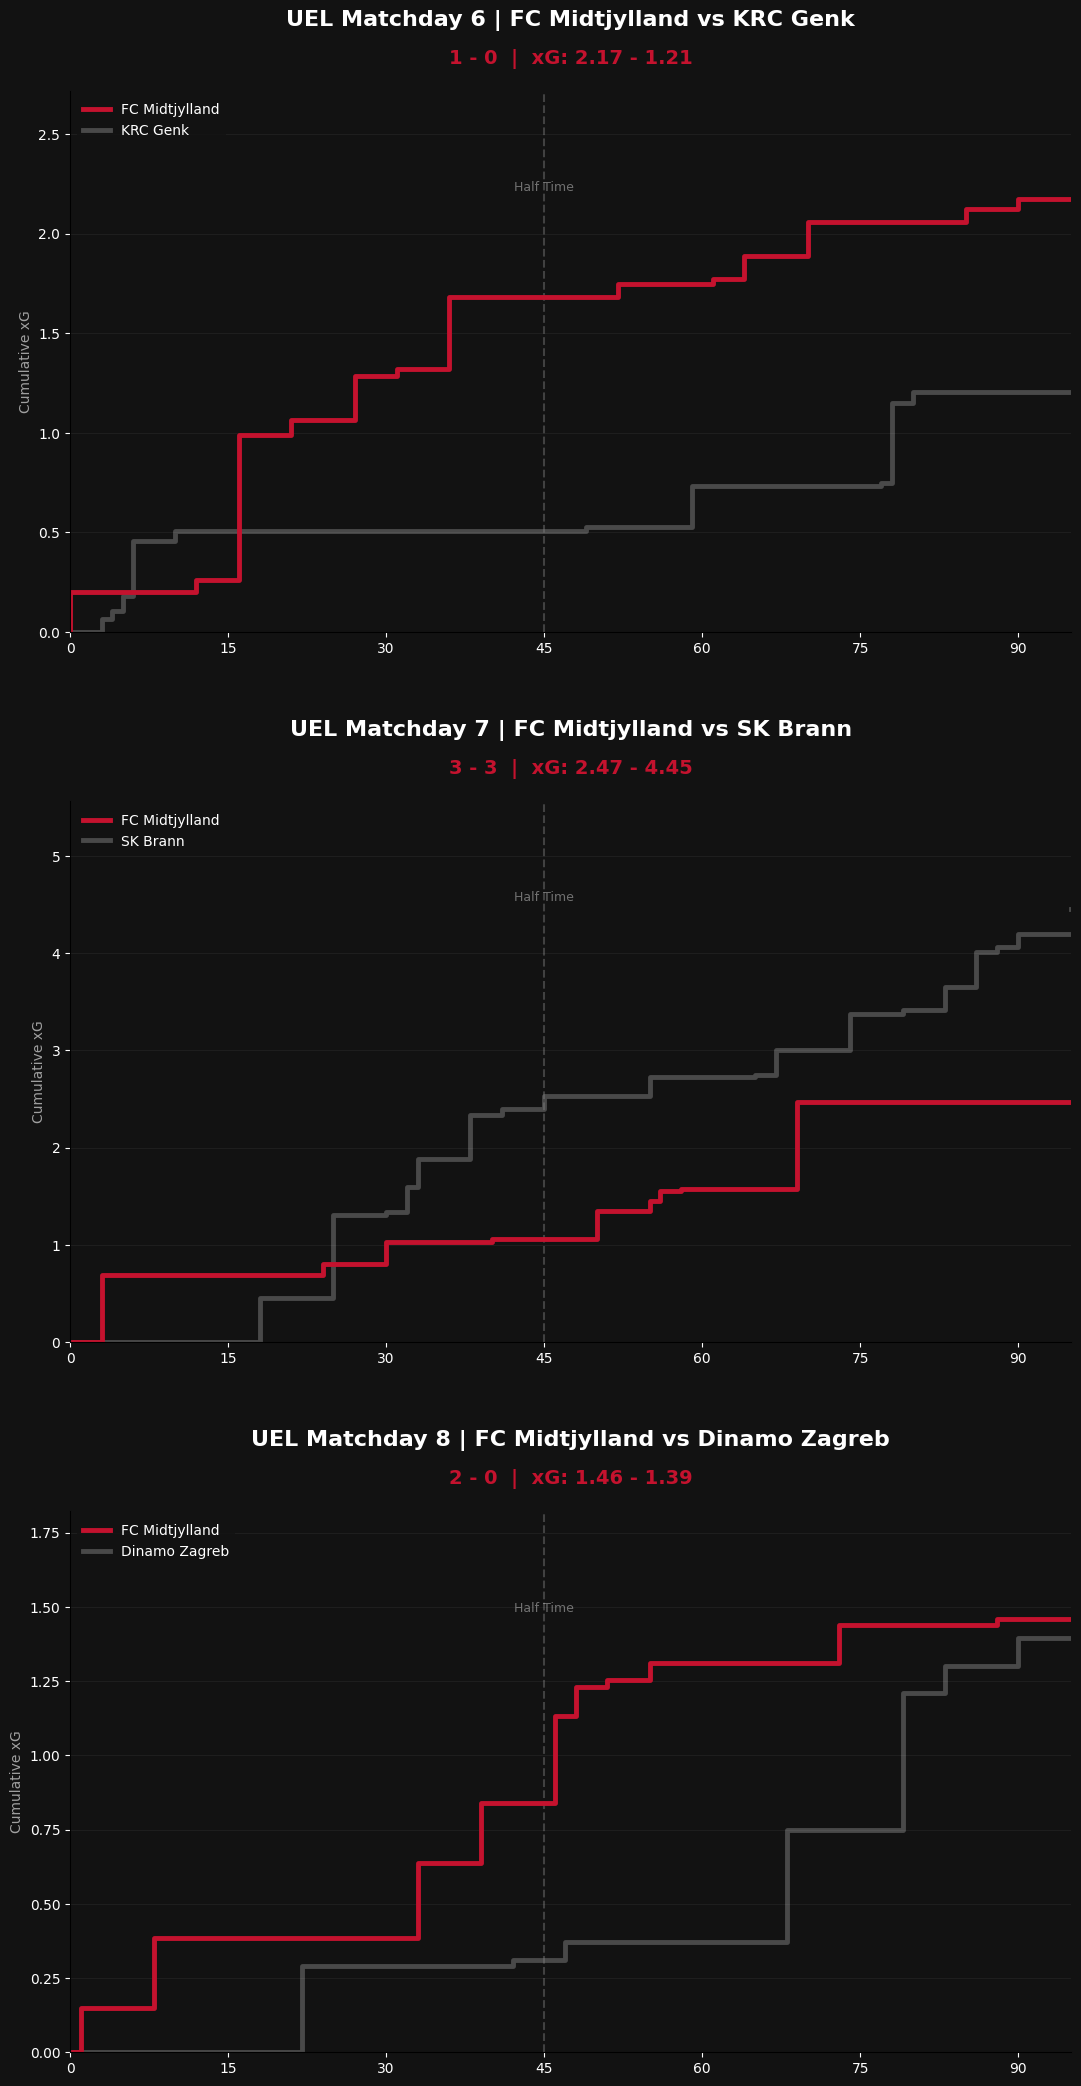

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from urllib.request import urlopen
import numpy as np
import pandas as pd
import os

# --- 1. CONFIGURACIÓN DEL BALÓN ---
ball_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Soccerball.svg/120px-Soccerball.svg.png"
try:
    ball_img = Image.open(urlopen(ball_url))
except:
    ball_img = None

def plot_ball(ax, x, y, zoom=0.18):
    if ball_img:
        imagebox = OffsetImage(ball_img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, zorder=10)
        ax.add_artist(ab)

# --- 2. CÁLCULO DE xG ---
def calculate_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    return np.exp(-0.12 * distancia)

# --- 3. GENERACIÓN DEL GRÁFICO CORREGIDO ---
fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 22))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    # Filtrar tiros
    df_shots = df_match[df_match['typeId'].isin([13, 14, 15, 16])].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_xg(row.x, row.y), axis=1)

    # Contar goles para el marcador
    goals_fcm = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    # Separar por equipos
    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    # --- FUNCIÓN CORREGIDA (Sincronización X e Y) ---
    def get_cum_data(shots_df):
        # X: 0, minutos de tiros, y final (95)
        x_vals = [0] + shots_df['timeMin'].tolist() + [95]
        # Y: 0, sumas acumuladas, y repetimos el último valor para que la línea sea plana al final
        cum_sum = np.cumsum(shots_df['xG']).tolist()
        last_val = cum_sum[-1] if cum_sum else 0
        y_vals = [0] + cum_sum + [last_val]
        return x_vals, y_vals

    fcm_x, fcm_y = get_cum_data(fcm_shots)
    opp_x, opp_y = get_cum_data(opp_shots)

    # Dibujar líneas de "escalera"
    ax.step(fcm_x, fcm_y, where='post', color='#C4122E', linewidth=3.5, label='FC Midtjylland', zorder=2)
    ax.step(opp_x, opp_y, where='post', color='#808080', linewidth=3.5, label=config['opponent'], alpha=0.5, zorder=1)

    # Poner balones en los goles
    for team_shots in [fcm_shots, opp_shots]:
        for _, goal in team_shots[team_shots['typeId'] == 16].iterrows():
            cum_at_moment = team_shots[team_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
            plot_ball(ax, goal['timeMin'], cum_at_moment)

    # --- TÍTULOS CENTRADOS ---
    title_l1 = f"{config['label']} | FC Midtjylland vs {config['opponent']}"
    title_l2 = f"{goals_fcm} - {goals_opp}  |  xG: {fcm_y[-1]:.2f} - {opp_y[-1]:.2f}"

    ax.text(0.5, 1.12, title_l1, transform=ax.transAxes, color='white', fontsize=16, weight='bold', ha='center')
    ax.text(0.5, 1.05, title_l2, transform=ax.transAxes, color='#C4122E', fontsize=14, weight='bold', ha='center')

    # --- LÍNEA DE HALF TIME ---
    ax.axvline(45, color='white', linestyle='--', alpha=0.2, zorder=0)
    ax.text(45, ax.get_ylim()[1]*0.97, 'Half Time', color='white', alpha=0.4, ha='center', fontsize=9)

    # Configuración de Ejes
    ax.set_xticks([0, 15, 30, 45, 60, 75, 90])
    ax.set_xlim(0, 95)
    ax.set_ylim(0, max(fcm_y[-1], opp_y[-1]) * 1.25)
    ax.grid(axis='y', color='white', alpha=0.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')
    ax.set_ylabel('Cumulative xG', color='white', alpha=0.6)
    ax.legend(loc='upper left', facecolor='#121212', edgecolor='none', labelcolor='white')

plt.tight_layout(pad=5.0)
plt.show()

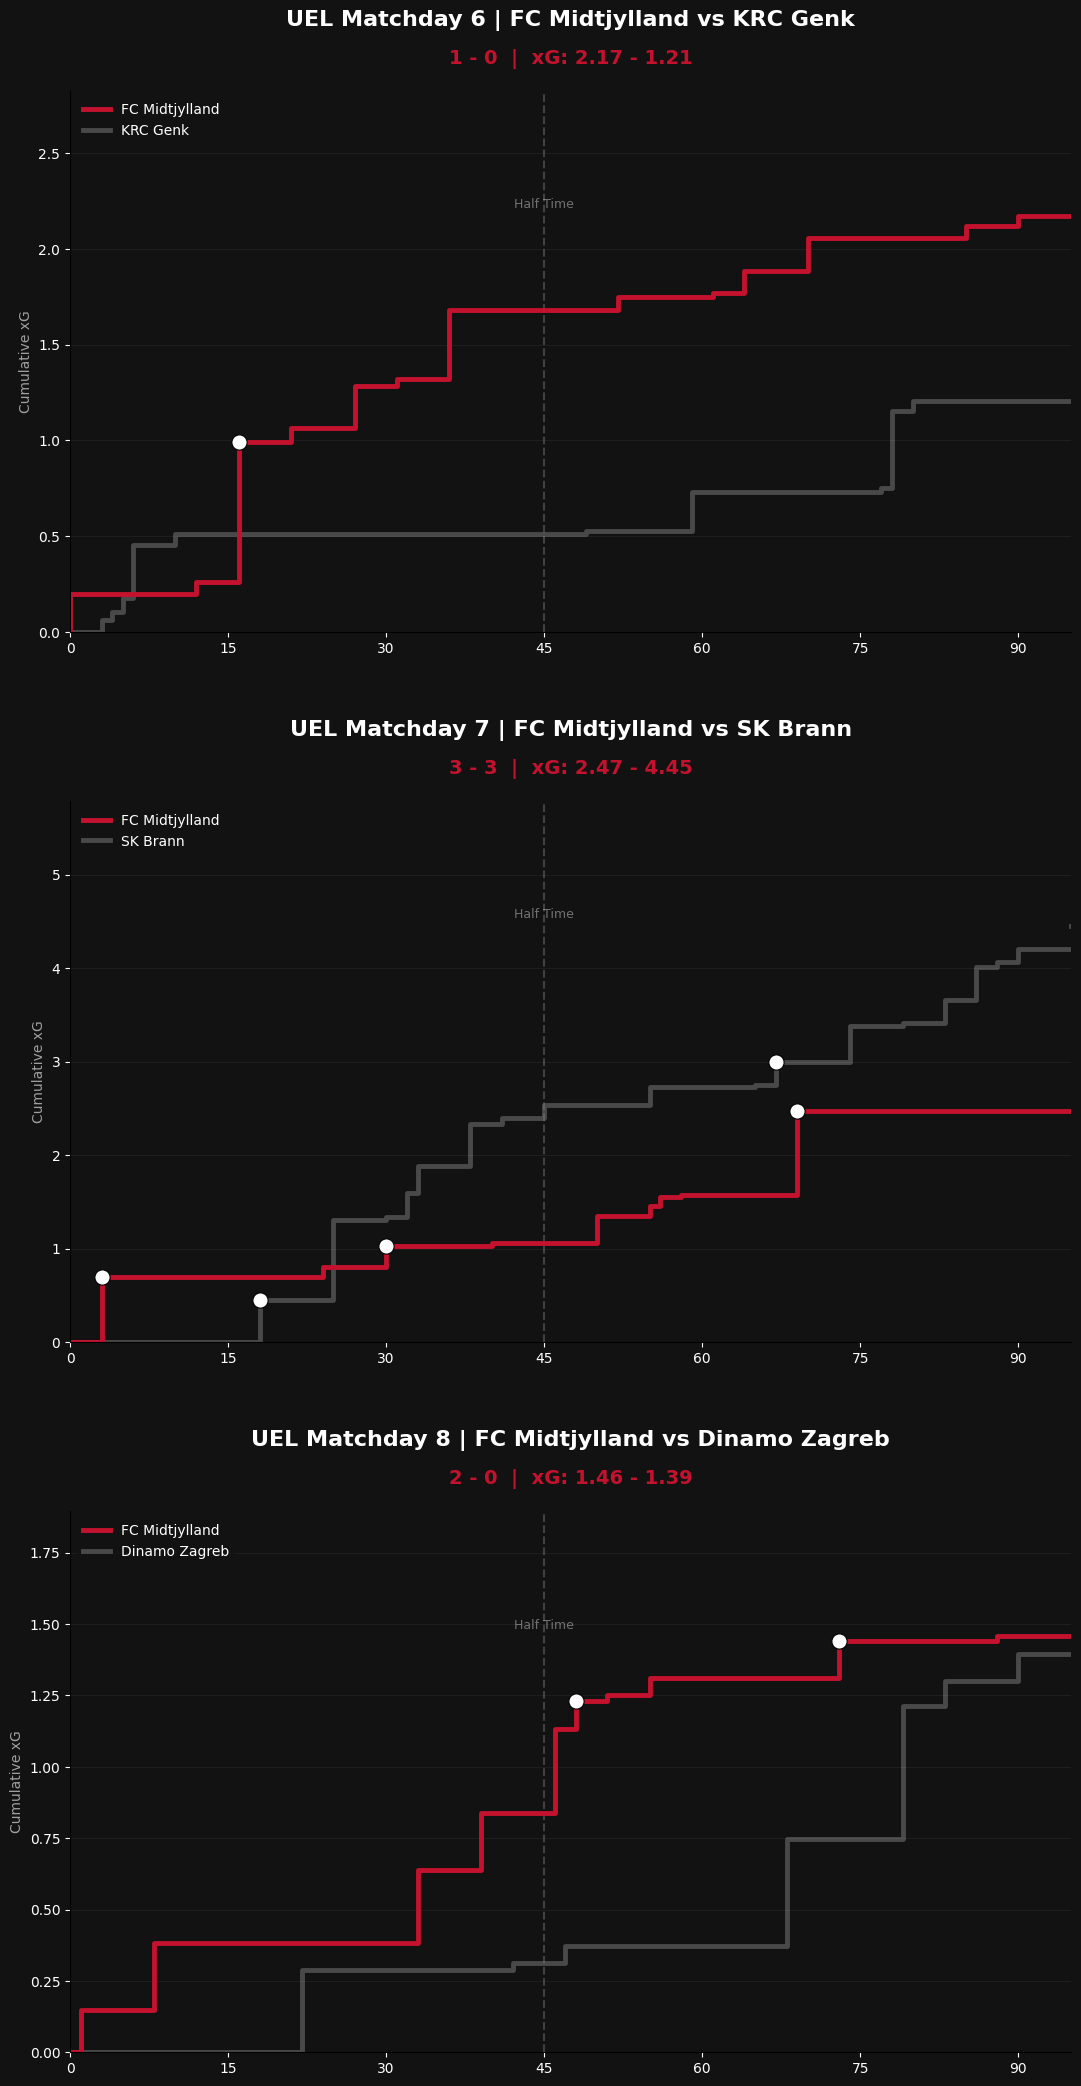

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from PIL import Image
from urllib.request import urlopen
import numpy as np
import pandas as pd
import os

# --- 1. CONFIGURACIÓN DEL ICONO DE GOL ---
ball_url = "https://upload.wikimedia.org/wikipedia/commons/thumb/d/d3/Soccerball.svg/120px-Soccerball.svg.png"
try:
    ball_img = Image.open(urlopen(ball_url))
except:
    ball_img = None

def plot_goal_marker(ax, x, y, zoom=0.15):
    # Si la imagen cargó, la ponemos
    if ball_img:
        imagebox = OffsetImage(ball_img, zoom=zoom)
        ab = AnnotationBbox(imagebox, (x, y), frameon=False, zorder=20)
        ax.add_artist(ab)
    # SIEMPRE ponemos un pequeño punto blanco debajo o como respaldo para asegurar visibilidad
    ax.scatter(x, y, s=120, color='white', edgecolors='black', linewidth=0.8, zorder=15)

# --- 2. CÁLCULO DE xG ---
def calculate_xg(x, y):
    dist_x = 100 - x
    dist_y = abs(50 - y)
    distancia = np.sqrt(dist_x**2 + dist_y**2)
    return np.exp(-0.12 * distancia)

# --- 3. GENERACIÓN DEL GRÁFICO ---
fig, axs = plt.subplots(nrows=len(matches_config), ncols=1, figsize=(12, 22))
fig.set_facecolor('#121212')

for i, config in enumerate(matches_config):
    # Carga de datos
    df_match = pd.read_csv(os.path.join(path_processed, config["file"]))
    fcm_id = df_match.groupby('contestantId').size().idxmax()

    ax = axs[i]
    ax.set_facecolor('#121212')

    # Procesar tiros
    df_shots = df_match[df_match['typeId'].isin([13, 14, 15, 16])].copy()
    df_shots['xG'] = df_shots.apply(lambda row: calculate_xg(row.x, row.y), axis=1)

    # Marcador
    goals_fcm = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] == fcm_id)])
    goals_opp = len(df_match[(df_match['typeId'] == 16) & (df_match['outcome'] == 1) & (df_match['contestantId'] != fcm_id)])

    # Separar equipos
    fcm_shots = df_shots[df_shots['contestantId'] == fcm_id].sort_values('timeMin')
    opp_shots = df_shots[df_shots['contestantId'] != fcm_id].sort_values('timeMin')

    # Función acumulada corregida (Sincronizada)
    def get_cum_data(shots_df):
        x_vals = [0] + shots_df['timeMin'].tolist() + [95]
        cum_sum = np.cumsum(shots_df['xG']).tolist()
        last_val = cum_sum[-1] if cum_sum else 0
        y_vals = [0] + cum_sum + [last_val]
        return x_vals, y_vals

    fcm_x, fcm_y = get_cum_data(fcm_shots)
    opp_x, opp_y = get_cum_data(opp_shots)

    # Dibujar líneas (Step)
    ax.step(fcm_x, fcm_y, where='post', color='#C4122E', linewidth=3.5, label='FC Midtjylland', zorder=2)
    ax.step(opp_x, opp_y, where='post', color='#808080', linewidth=3.5, label=config['opponent'], alpha=0.5, zorder=1)

    # --- DIBUJAR LOS GOLES (IMPORTANTE) ---
    # Goles FCM
    for _, goal in fcm_shots[fcm_shots['typeId'] == 16].iterrows():
        # Calculamos la altura acumulada justo en ese tiro
        cum_at_moment = fcm_shots[fcm_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        plot_goal_marker(ax, goal['timeMin'], cum_at_moment)

    # Goles Rival
    for _, goal in opp_shots[opp_shots['typeId'] == 16].iterrows():
        cum_at_moment = opp_shots[opp_shots['timeMin'] <= goal['timeMin']]['xG'].sum()
        plot_goal_marker(ax, goal['timeMin'], cum_at_moment)

    # --- TÍTULOS CENTRADOS ---
    title_l1 = f"{config['label']} | FC Midtjylland vs {config['opponent']}"
    title_l2 = f"{goals_fcm} - {goals_opp}  |  xG: {fcm_y[-1]:.2f} - {opp_y[-1]:.2f}"

    ax.text(0.5, 1.12, title_l1, transform=ax.transAxes, color='white', fontsize=16, weight='bold', ha='center')
    ax.text(0.5, 1.05, title_l2, transform=ax.transAxes, color='#C4122E', fontsize=14, weight='bold', ha='center')

    # --- LÍNEA DE DESCANSO ---
    ax.axvline(45, color='white', linestyle='--', alpha=0.2, zorder=0)
    ax.text(45, ax.get_ylim()[1]*0.97, 'Half Time', color='white', alpha=0.4, ha='center', fontsize=9)

    # Configuración de Ejes
    ax.set_xticks([0, 15, 30, 45, 60, 75, 90])
    ax.set_xlim(0, 95)
    ax.set_ylim(0, max(fcm_y[-1], opp_y[-1], 0.5) * 1.3) # Aseguramos espacio arriba
    ax.grid(axis='y', color='white', alpha=0.05)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(colors='white')
    ax.set_ylabel('Cumulative xG', color='white', alpha=0.6)
    ax.legend(loc='upper left', facecolor='#121212', edgecolor='none', labelcolor='white')

plt.tight_layout(pad=5.0)
fig_timeline = fig
plt.show()

Version Final. Exportar.


In [ ]:
from matplotlib.backends.backend_pdf import PdfPages

# Ruta donde quieres que se guarde
ruta = '/content/drive/MyDrive/TFM_Analisis_de_Datos/Data/Processed/Reporte_Final_FCM.pdf'

with PdfPages(ruta) as pdf:
    pdf.savefig(fig_shots, bbox_inches='tight', facecolor='#121212')
    pdf.savefig(fig_timeline, bbox_inches='tight', facecolor='#121212')

print("🚀 ¡Reporte guardado con éxito!")

🚀 ¡Reporte guardado con éxito!
